# Aufgabenbeschreibung

## Datenbeschreibung

Das Land Berlin veröffentlicht jährlich detaillierte Informationen zu staatlichen Zuwendungen. Der Datensatz sowie die Datendefinitionen sind über die Zuwendungsdatenbank verfügbar:

- https://www.berlin.de/sen/finanzen/service/zuwendungsdatenbank/

## Klassifizierungsaufgabe

Ziel ist die Entwicklung eines Klassifikators, der anhand der verfügbaren Merkmale den jeweiligen `politikbereich` vorhersagen kann.

## Rahmenbedingungen

Die Lösung soll in einer vergleichbaren Arbeitsumgebung entwickelt werden. Empfohlene Werkzeuge und Anforderungen sind:

- Pandas, nltk, scikit-learn, keras und matplotlib,
- Jupyter Notebooks als Abgabeformat,
- Auswertung und Visualisierung der Ergebnisse,
- kurze Präsentation der Ergebnisse für Fachexperten und Vorstand.

Dafür werden alle notwendigen Schritte von der Datenprüfung über die Vorverarbeitung bis zur Modellvorbereitung nachvollziehbar dokumentiert.

# 0. Problemdefinition

## 0.1. Allgemein

**Zielspalte:** `politikbereich`

**Problemtyp:** Single-Label-Mehrklassenklassifikation

Jeder Datensatz soll genau einem Politikbereich zugeordnet werden. Die Klassifikation basiert auf textuellen, kategorialen und numerischen Merkmalen. Da die Zielvariable deutlich unausgewogen ist, müssen Modellauswahl und Evaluation besonders sorgfältig erfolgen.

## 0.2 Definition der Evaluationsmetriken

Bei der vorliegenden Aufgabe handelt es sich um ein **Mehrklassen-Klassifikationsproblem**, bei dem Texte einem bestimmten Politikbereich zugeordnet werden. Da die Klassen im Datensatz unterschiedlich häufig vertreten sind, reicht eine einzelne Kennzahl wie die Accuracy nicht aus.

Insbesondere große Klassen könnten die Gesamtbewertung dominieren, während eine schlechte Erkennungsleistung bei kleineren Klassen unbemerkt bliebe. Deshalb werden mehrere, sich ergänzende Evaluationsmetriken verwendet.

### 0.2.1. Erklärung der Evaluationsmetriken

#### TP, TN, FP und FN

Die Vorhersagen eines Modells werden in vier Fälle unterteilt:

| Abkürzung | Tatsächlicher Wert | Vorhersage | Bedeutung |
|---|---|---|---|
| **TP** | Positiv | Positiv | Etwas Positives wird richtig als positiv erkannt. |
| **TN** | Negativ | Negativ | Etwas Negatives wird richtig als negativ erkannt. |
| **FP** | Negativ | Positiv | Etwas Negatives wird fälschlicherweise als positiv erkannt. |
| **FN** | Positiv | Negativ | Etwas Positives wird fälschlicherweise als negativ erkannt. |

- **True:** Die Vorhersage ist richtig.
- **False:** Die Vorhersage ist falsch.
- **Positive:** Das Modell sagt „Ja“.
- **Negative:** Das Modell sagt „Nein“.

#### Precision, Recall und F1-Score

Neben den aggregierten Kennzahlen werden Precision, Recall und F1-Score für jeden Politikbereich einzeln ausgewertet.

**Precision**

Die Precision beantwortet die Frage:

> Wenn das Modell einen bestimmten Politikbereich vorhersagt, wie häufig ist diese Vorhersage korrekt?

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

Eine niedrige Precision bedeutet, dass viele Dokumente fälschlicherweise dieser Klasse zugeordnet werden.

**Recall**

Der Recall beantwortet die Frage:

> Wie viele der tatsächlich zu einem bestimmten Politikbereich gehörenden Dokumente werden vom Modell erkannt?

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

Ein niedriger Recall bedeutet, dass viele Fälle einer Klasse übersehen und stattdessen anderen Politikbereichen zugeordnet werden.

**F1-Score**

Der F1-Score fasst Precision und Recall zu einer gemeinsamen Kennzahl zusammen. Die klassenweise Auswertung ist notwendig, weil ein globaler Mittelwert nicht erkennen lässt, welche konkreten Politikbereiche problematisch sind.

Sie ermöglicht eine gezielte Fehleranalyse und zeigt, für welche Klassen beispielsweise folgende Maßnahmen erforderlich sein könnten:

- zusätzliche Trainingsdaten,
- eine präzisere Klassendefinition,
- eine bessere Repräsentation der Texte,
- eine Überprüfung der Annotationen.

### 0.2.2 Evaluationsmetriken

Da die Zielvariable „politikbereich“ eine deutliche Klassenunverteilung aufweist, ist die reine Accuracy als Evaluationsmetrik nur eingeschränkt geeignet. Große Klassen wie „Wirtschaft“, „Arbeit“, „Sport“ oder „Jugend“ dominieren die Datenbasis, während einzelne Klassen wie „Berlin-Image“, „Tierschutz“, „Finanzen“, „Medien“ oder „Internationales“ nur sehr wenige Beobachtungen enthalten. Ein Modell könnte daher eine hohe Accuracy erreichen, indem es vor allem die häufigen Klassen gut vorhersagt, während die seltenen Klassen kaum korrekt erkannt werden.

Auch in der Literatur wird dieses Problem für unausgewogene Klassifikationsaufgaben beschrieben. He und Garcia (2009) zeigen in ihrem Überblick zu Imbalanced Learning, dass klassische Lernverfahren bei stark unterrepräsentierten Klassen häufig schlechtere Ergebnisse erzielen und dass Standardmetriken wie Accuracy die tatsächliche Modellleistung verzerren können. Deshalb werden für diese Arbeit zusätzlich klassenbezogene Metriken verwendet.

Für die Bewertung des Modells werden daher neben der Accuracy insbesondere Precision, Recall und F1-Score betrachtet. Dabei ist der Macro-F1-Score besonders wichtig, weil er jede Klasse unabhängig von ihrer Häufigkeit gleich stark gewichtet. Der Weighted-F1-Score ergänzt diese Sicht, da er die tatsächliche Klassenverteilung berücksichtigt. Zusätzlich werden die Ergebnisse pro Klasse ausgewiesen, damit sichtbar bleibt, ob das Modell nur die großen Klassen gut erkennt oder auch bei kleineren Politikbereichen brauchbare Vorhersagen liefert.

Klassen mit sehr geringer Fallzahl werden nicht automatisch entfernt oder größeren Klassen zugeordnet. Stattdessen werden sie in der Evaluation als Klassen mit geringer statistischer Belastbarkeit betrachtet. Dadurch bleibt die ursprüngliche Zielstruktur erhalten, gleichzeitig werden die Kennzahlen für seltene Klassen vorsichtig interpretiert.

Quelle: He, H. und Garcia, E. A. (2009): Learning from Imbalanced Data. IEEE Transactions on Knowledge and Data Engineering. https://ieeexplore.ieee.org/document/5128907

#### Hauptmetrik: Macro-F1

Der **Macro-F1-Score** berechnet den F1-Score für jede Klasse und bildet daraus den Durchschnitt. Dabei zählt jede Klasse gleich viel – unabhängig davon, wie häufig sie vorkommt.

Diese Metrik ist besonders wichtig, weil sie zeigt, ob das Modell sowohl häufige als auch seltene Politikbereiche zuverlässig erkennt.





#### Weitere Metriken

- **Weighted-F1:** Berücksichtigt die Häufigkeit der Klassen. Häufige Klassen haben dadurch einen größeren Einfluss.
- **Balanced Accuracy:** Berechnet die durchschnittliche Erkennungsrate aller Klassen. Jede Klasse wird gleich gewichtet.
- **Accuracy:** Zeigt den Anteil aller richtigen Vorhersagen. Bei ungleich verteilten Klassen kann dieser Wert jedoch irreführend sein.
- **Precision, Recall und F1 pro Klasse:** Zeigen, bei welchen Politikbereichen das Modell gut oder schlecht funktioniert.

#### Konfusionsmatrix

Die **Konfusionsmatrix** zeigt, welche Klassen korrekt erkannt und welche miteinander verwechselt werden.

- **Zeilen:** tatsächliche Klassen
- **Spalten:** vorhergesagte Klassen
- **Diagonale:** korrekte Vorhersagen
- **Andere Felder:** Fehlklassifikationen

#### Übersicht













| Metrik | Zweck |
|---|---|
| **Macro-F1** | Gleichwertige Bewertung aller Klassen |
| **Weighted-F1** | Bewertung entsprechend der Klassenhäufigkeit |
| **Balanced Accuracy** | Durchschnittliche Erkennungsrate aller Klassen |
| **Accuracy** | Anteil aller korrekten Vorhersagen |
| **Metriken pro Klasse** | Erkennung problematischer Klassen |
| **Konfusionsmatrix** | Darstellung typischer Verwechslungen |

Der **Macro-F1-Score** wird als Hauptmetrik verwendet, da er bei einer ungleichen Klassenverteilung eine faire Gesamtbewertung ermöglicht.

## 0.3. DataFrame vorbereiten

Der ursprüngliche DataFrame wird kopiert, damit die explorative Analyse und die spätere Vorverarbeitung nachvollziehbar durchgeführt werden können, ohne die Rohdaten zu verändern.

In [854]:
from pathlib import Path
import pandas as pd
from IPython.display import display

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "raw" / "index.csv"

df_raw = pd.read_csv(data_path, sep=";", encoding="utf-8")

df = df_raw.copy()

df.head()

,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
0,1,"""AUSLÄNDER MIT UNS"" - Verein zur Förderung int...",Bezirksamt Tempelhof-Schöneberg,Projektförderung,2022,"Geßlerstraße 11, 10829 Berlin",Integration,Vernetzung und Information aller Migrant_innen...,1724,vr_004960
1,4,» mehrSicht « jugend*kultur*bildung e. V.,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,2024,"Pirolstraße 82, 12683 Berlin",Wirtschaft,Solidarischeres Handeln? Welthandel erkunden f...,4000,vr_038196
2,7,e. V.SV Preußen Berlin e. V.,Senatsverwaltung für Inneres und Sport,Projektförderung,2021,"Hansastraße 190, 13088 Berlin",Sport,Kosten für die Beschäftigung von hauptberuflic...,4070,vr_011425
3,10,ITS Training Gesellschaft mit beschränkter Haf...,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,2021,"Am Oder-Spree-Kanal 23D, 12527 Berlin",Wirtschaft,Digitalprämie Berlin,4066,hrb_084522
4,13,it's.BB e. V.,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,2024,"Poßweg 45, 14163 Berlin",Wirtschaft,Etabilierung einer regionalen IT-/Cybersecurit...,464891,vr_037100


# 1. EDA (Explorative Data Analysis) vor Datenvorbereitung

Eine hohe Datenqualität bildet die Grundlage für leistungsfähige und zuverlässige Modelle. Fehlerhafte, unvollständige oder ungeeignete Daten können die Modellleistung beeinträchtigen und zu unzuverlässigen Vorhersagen führen. Daher werden die vorliegenden Daten zunächst sorgfältig untersucht und bei Bedarf bereinigt (vgl. Mohammed et al., 2025). 

Unter qualitativ hochwertigen Daten werden in dieser Arbeit Daten verstanden, die korrekt, vollständig, konsistent und für die Klassifikationsaufgabe relevant sind. Darüber hinaus sollten die verschiedenen Politikbereiche ausreichend repräsentiert und die Dokumente möglichst korrekt annotiert sein. Duplikate, fehlerhafte Werte, uneinheitliche Schreibweisen und Datenlecks sollten vermieden werden.

##### Literatur
Mohammed, S., Budach, L., Feuerpfeil, M., Ihde, N., Nathansen, A., Noack, N., Patzlaff, H., Naumann, F. & Harmouch, H. (2025). *The Effects of Data Quality on Machine Learning Performance on Tabular Data*. Information Systems, 132, 102549. https://doi.org/10.1016/j.is.2025.102549

## 1.1. Allgemeine Untersuchung der Datenstruktur

### 1.1.1. Datenstruktur und -qualität

In [855]:
display(df.head())

# Datenstruktur anzeigen
df.info()

,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
0,1,"""AUSLÄNDER MIT UNS"" - Verein zur Förderung int...",Bezirksamt Tempelhof-Schöneberg,Projektförderung,2022,"Geßlerstraße 11, 10829 Berlin",Integration,Vernetzung und Information aller Migrant_innen...,1724,vr_004960
1,4,» mehrSicht « jugend*kultur*bildung e. V.,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,2024,"Pirolstraße 82, 12683 Berlin",Wirtschaft,Solidarischeres Handeln? Welthandel erkunden f...,4000,vr_038196
2,7,e. V.SV Preußen Berlin e. V.,Senatsverwaltung für Inneres und Sport,Projektförderung,2021,"Hansastraße 190, 13088 Berlin",Sport,Kosten für die Beschäftigung von hauptberuflic...,4070,vr_011425
3,10,ITS Training Gesellschaft mit beschränkter Haf...,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,2021,"Am Oder-Spree-Kanal 23D, 12527 Berlin",Wirtschaft,Digitalprämie Berlin,4066,hrb_084522
4,13,it's.BB e. V.,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,2024,"Poßweg 45, 14163 Berlin",Wirtschaft,Etabilierung einer regionalen IT-/Cybersecurit...,464891,vr_037100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57469 entries, 0 to 57468
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57469 non-null  int64 
 1   name            57469 non-null  object
 2   geber           57469 non-null  object
 3   art             57469 non-null  object
 4   jahr            57469 non-null  int64 
 5   anschrift       57469 non-null  object
 6   politikbereich  57469 non-null  object
 7   zweck           57468 non-null  object
 8   betrag          57469 non-null  int64 
 9   empfaengerid    55987 non-null  object
dtypes: int64(3), object(7)
memory usage: 4.4+ MB


### 1.1.2. Datenqualität

In [856]:
# Fehlende Werte anzeigen
print("Fehlende Werte:")
display(df.isna().sum().to_frame("Anzahl"))

# Eindeutige Werte anzeigen
print("Eindeutige Werte:")
display(df.nunique().to_frame("Anzahl"))

# Alle Duplikate anzeigen
duplicates = df[df.duplicated()]

print(f"Anzahl der doppelten Zeilen: {len(duplicates)}")
display(duplicates)

Fehlende Werte:


,Anzahl
id,0
name,0
geber,0
art,0
jahr,0
anschrift,0
politikbereich,0
zweck,1
betrag,0
empfaengerid,1482


Eindeutige Werte:


,Anzahl
id,57469
name,13393
geber,43
art,3
jahr,5
anschrift,12125
politikbereich,34
zweck,26875
betrag,28630
empfaengerid,10685


Anzahl der doppelten Zeilen: 0


,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid


#### Ergebnis

Der Datensatz besteht aus **57.469 Zeilen** und **10 Spalten**. Es wurden keine vollständig doppelten Zeilen gefunden.

Bei den fehlenden Werten fallen insbesondere zwei Spalten auf:

- `zweck`: 1 fehlender Wert,
- `empfaengerid`: 1.482 fehlende Werte.

Die fehlenden Empfänger-IDs sind für die spätere Datenbereinigung besonders relevant, da sie als wichtiges Organisationsmerkmal verwendet werden können.

### 1.1.3. Untersuchung auf Auffälligkeiten in numerischen Spalten

#### Ungültige Jahresangaben

Die Spalte `jahr` wird auf fehlende, nicht numerische und unrealistische Jahresangaben überprüft.

In [857]:
year_numeric = pd.to_numeric(df["jahr"], errors="coerce")

current_year = pd.Timestamp.now().year

invalid_year_mask = (
    (df["jahr"].notna() & year_numeric.isna())
    | (year_numeric < 1900)
    | (year_numeric > current_year)
)

invalid_years = df.loc[invalid_year_mask, ["id", "jahr"]]

print(f"Aktuelles Jahr: {current_year}")
print(f"Anzahl ungültiger Jahresangaben: {len(invalid_years)}")

Aktuelles Jahr: 2026
Anzahl ungültiger Jahresangaben: 0


#### Untersuchung der Beträge

Da in diesem Datensatz auch berechtigterweise sehr hohe Förderbeträge vorkommen können, werden hohe Werte nicht automatisch als Ausreißer betrachtet. Stattdessen werden Minimum, Maximum, Durchschnitt und Median untersucht.

In [858]:
# Die Betragsspalte sicher in numerische Werte umwandeln
betrag_numeric = pd.to_numeric(df["betrag"], errors="coerce")

# Grundlegende statistische Kennzahlen berechnen
betrag_statistik = pd.DataFrame(
    {
        "Kennzahl": ["Minimum", "Maximum", "Durchschnitt", "Median"],
        "Betrag": [
            betrag_numeric.min(),
            betrag_numeric.max(),
            betrag_numeric.mean(),
            betrag_numeric.median(),
        ],
    }
)


# Zahlen im deutschen Format darstellen
def format_euro(value):
    return f"{value:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".") + " €"


betrag_statistik["Betrag in Euro"] = betrag_statistik["Betrag"].map(format_euro)

display(betrag_statistik[["Kennzahl", "Betrag in Euro"]])

,Kennzahl,Betrag in Euro
0,Minimum,"100,00 €"
1,Maximum,"114.826.400,00 €"
2,Durchschnitt,"236.660,67 €"
3,Median,"29.500,00 €"


#### Ergebnis

Die Beträge weisen eine stark unterschiedliche Höhe auf. Einzelne sehr hohe Förderbeträge erhöhen den Durchschnitt deutlich, während der Median robuster gegenüber diesen Extremwerten ist. Daher wird die Verteilung der Beträge später zusätzlich transformiert, bevor sie als numerisches Merkmal in der Modellierung verwendet wird.

## 1.2. Untersuchung der Klassenspalte "Politikbereich"

'Anyahl der Klassen: 34'

<Figure size 1000x1000 with 0 Axes>

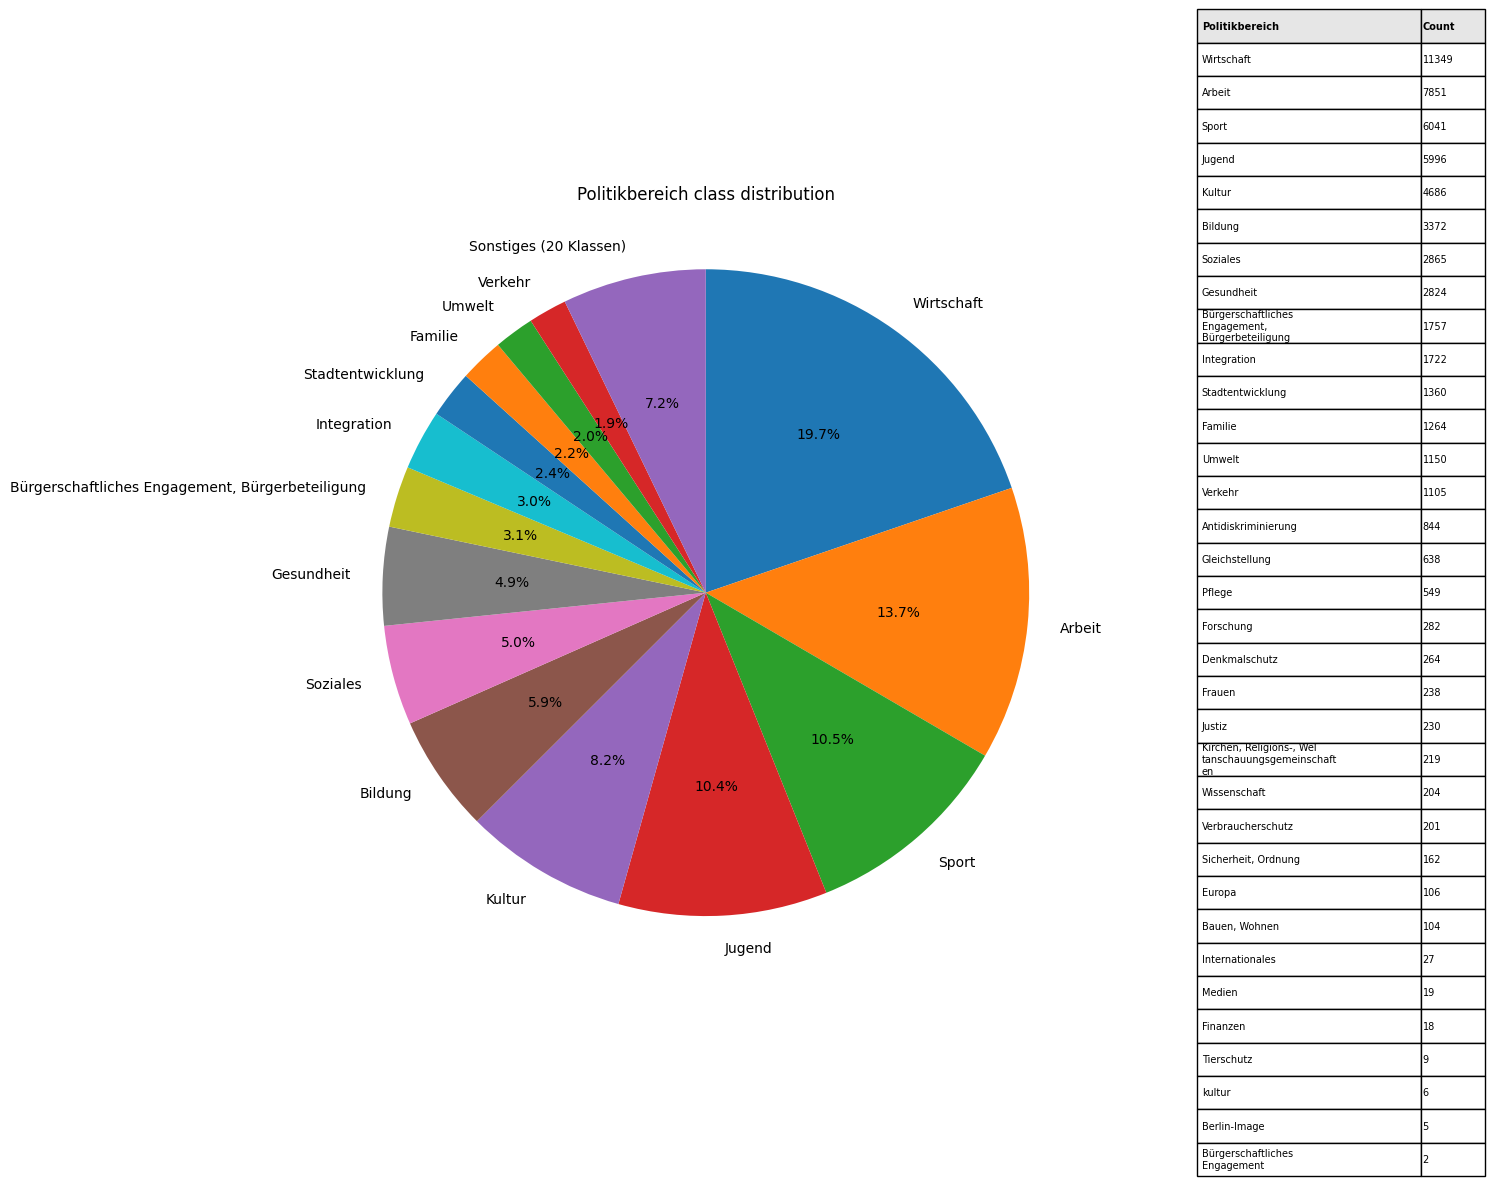

In [859]:
import textwrap
import matplotlib.pyplot as plt

# count how many classes are in the column
num_classes = df["politikbereich"].nunique()

# count how many values are in each class and normalize the counts
counts = df["politikbereich"].value_counts()
normalized_counts = df["politikbereich"].value_counts(normalize=True)
display(f"Anyahl der Klassen: {num_classes}")
# display(counts.to_frame('count'))
# display(normalized_counts.to_frame('normalized_count'))

# pie chart of the class distribution
plt.figure(figsize=(10, 10))

# Pie chart 데이터
filtered_counts = normalized_counts[normalized_counts >= 0.019]
other_counts = normalized_counts[normalized_counts < 0.019]

final_counts = pd.concat(
    [
        filtered_counts,
        pd.Series({f"Sonstiges ({len(other_counts)} Klassen)": other_counts.sum()}),
    ]
)

# 표 데이터
table_data = counts.to_frame("Count").reset_index()
table_data.columns = ["Politikbereich", "Count"]

# 긴 클래스명 줄바꿈
table_data["Politikbereich"] = table_data["Politikbereich"].apply(
    lambda value: "\n".join(textwrap.wrap(str(value), width=24))
)

# Pie 영역을 크게, 표 영역을 작게 설정
fig, (ax_pie, ax_table) = plt.subplots(
    1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [4.5, 1.5], "wspace": 0.05}
)

# Pie chart
ax_pie.pie(
    final_counts.values,
    labels=final_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    radius=1.05,
)
ax_pie.set_title("Politikbereich class distribution")

# 표
ax_table.axis("off")

table = ax_table.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.78, 0.22],  # 이름 열은 넓게, Count 열은 좁게
)

# 글자와 셀 크기 축소
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(0.95, 2)

# 셀 안에서 글자가 잘리지 않도록 설정
for (row, col), cell in table.get_celld().items():
    cell.get_text().set_wrap(True)
    cell.PAD = 0.02

    # 헤더 스타일
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#E6E6E6")

plt.show()

In [860]:
display(df.loc[df["politikbereich"] == "Bürgerschaftliches Engagement"].head())
display(
    df.loc[
        df["politikbereich"] == "Bürgerschaftliches Engagement, Bürgerbeteiligung"
    ].head()
)

,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
32835,98506,Landesfreiwilligenagentur Berlin e. V.,Regierende Bürgermeisterin/Regierender Bürgerm...,Projektförderung,2023,"Schumannstraße 3, 10177 Berlin",Bürgerschaftliches Engagement,Überbezirkliche Begleitung der Freiwilligenage...,60000,vr_006930
32836,98509,Landesfreiwilligenagentur Berlin e. V.,Regierende Bürgermeisterin/Regierender Bürgerm...,Projektförderung,2023,"Schumannstraße 3, 10177 Berlin",Bürgerschaftliches Engagement,Verstetigung der Arbeit der LAGFA Berlin e.V.,43900,vr_006930


,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
63,190,„Verschiedene Gesellschaften bürgerlichen Rechts,Bezirksamt Friedrichshain-Kreuzberg,Projektförderung,2023,'---',"Bürgerschaftliches Engagement, Bürgerbeteiligung","Bemalung Wandfläche Galilei-Grundschule, 17_20...",44662,NaN
64,193,„Verschiedene Gesellschaften bürgerlichen Rechts,Bezirksamt Friedrichshain-Kreuzberg,Projektförderung,2023,'---',"Bürgerschaftliches Engagement, Bürgerbeteiligung",Die Klinik der kaputten Dinge - das soziale Re...,34540,NaN
65,196,„Verschiedene Gesellschaften bürgerlichen Rechts,Bezirksamt Friedrichshain-Kreuzberg,Projektförderung,2023,'---',"Bürgerschaftliches Engagement, Bürgerbeteiligung","Förderung der Kiezidentität II, 17_2022000049_F",35000,NaN
66,199,„Verschiedene Gesellschaften bürgerlichen Rechts,Bezirksamt Friedrichshain-Kreuzberg,Projektförderung,2023,'---',"Bürgerschaftliches Engagement, Bürgerbeteiligung","Förderung der Kiezidentität, 12_2019011246",50000,NaN
219,658,1. Miniaturgolf-Verein Spandau e. V.,Bezirksamt Spandau,Projektförderung,2021,"Fehrbelliner Straße 14, 13585 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung","Instandsetzung Dach, Sanierung Bahnen, Umbau Z...",3500,vr_003782


In [861]:
df.loc[
    (df["politikbereich"] == "Bürgerschaftliches Engagement, Bürgerbeteiligung")
    & (df["name"] == "Landesfreiwilligenagentur Berlin e. V.")
]

,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
32834,98503,Landesfreiwilligenagentur Berlin e. V.,Regierende Bürgermeisterin - Senatskanzlei -,Projektförderung,2022,"Schumannstraße 3, 10117 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",13. Berliner Stiftungstag/15. Berliner Freiwil...,76000,vr_009630
32837,98512,Landesfreiwilligenagentur Berlin e. V.,Regierender Bürgermeister - Senatskanzlei -,Projektförderung,2020,"Schumannstraße 3, 10117 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",11. Berliner Stiftungstag/13. Berliner Freiwil...,70000,vr_009630
32838,98515,Landesfreiwilligenagentur Berlin e. V.,Regierender Bürgermeister - Senatskanzlei -,Projektförderung,2021,"Schumannstraße 3, 10117 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",12. Berliner Stiftungstag/14. Berliner Freiwil...,75067,vr_009630
32855,98566,Landesfreiwilligenagentur Berlin e. V.,Senatsverwaltung für Kultur und Gesellschaftli...,Projektförderung,2024,"Schumannstraße 3, 10117 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",Beratung zu Antisemitismus,44460,vr_009630
32856,98569,Landesfreiwilligenagentur Berlin e. V.,Senatsverwaltung für Kultur und Gesellschaftli...,Projektförderung,2024,"Schumannstraße 3, 10117 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",Berliner Frewilligenbörse 2024,50000,vr_009630
32857,98572,Landesfreiwilligenagentur Berlin e. V.,Senatsverwaltung für Kultur und Gesellschaftli...,Projektförderung,2024,"Schumannstraße 3, 10117 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",Koordinationsstelle Landesnetzwerk Bürgerschaf...,217255,vr_009630


In [862]:
df.loc[df["politikbereich"] == "kultur"]

,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
6464,19393,Berliner Ringtheater e. V.,Senatsverwaltung für Kultur und Europa,Projektförderung,2021,"Laskerstraße 5, 10245 Berlin",kultur,"Einbau, Anmietung und Betrieb einer mobilen Lü...",21891,vr_037559
12041,36124,cie. toula limnaios GmbH,Senatsverwaltung für Kultur und Europa,Projektförderung,2022,"Eberswalder Straße 10, 10437 Berlin",kultur,Temporäre Anmietung einer mobilen Lüftungsanla...,27721,hrb_216537
31753,95260,Kultur Büro Elisabeth gGmbH,Senatsverwaltung für Kultur und Europa,Projektförderung,2021,"Invalidenstraße 4 a, 10115 Berlin",kultur,"Einbau, Anmietung und Betrieb einer mobilen Lü...",39307,hrb_093879
41336,124009,Radialsystem V GmbH,Senatsverwaltung für Kultur und Europa,Projektförderung,2021,"Holzmarktstraße 33, 10243 Berlin",kultur,Temporäre Anmietung einer mobilen Lüftungsanla...,96566,hrb_098552
49911,149734,Theater Strahl gGmbH,Senatsverwaltung für Kultur und Europa,Projektförderung,2023,"Martin-Luther-Straße 77, 10825 Berlin",kultur,"Projekte ""Wir holen uns die Nacht zurück "" und...",108000,hrb_135079
51264,153793,Uferstudios GmbH,Senatsverwaltung für Kultur und Europa,Projektförderung,2021,"Uferstraße 23, 13357 Berlin",kultur,"Einbau,Anmietung und Betrieb einer mobilen Lüf...",30360,hrb_102201


#### Ergebnis

Der Datensatz weist ein deutliches Klassenungleichgewicht auf. Vor der Bereinigung enthält die Spalte `politikbereich` **34 Klassen**.

Dabei wurden zwei auffällige Fälle identifiziert:

- `kultur` ist eine abweichende Schreibweise von `Kultur`,
- `Bürgerschaftliches Engagement` scheint inhaltlich zur größeren Klasse `Bürgerschaftliches Engagement, Bürgerbeteiligung` zu gehören.

Diese Fälle werden im weiteren Verlauf standardisiert, sodass die Zielvariable konsistenter verwendet werden kann.

## 1.3. Überprüfung der restlichen Textdaten auf inkonsistente Schreibweisen

Da die Spalte `politikbereich` Schreibvarianten und Unterkategorien enthält, werden auch die übrigen Textspalten auf inkonsistente Schreibweisen geprüft. Dazu gehören `name`, `geber`, `art`, `anschrift`, `zweck` und `empfaengerid`.

Ziel ist es zu prüfen, ob uneinheitliche Groß- und Kleinschreibung, Abkürzungen, Sonderzeichen, Leerzeichen oder Tippfehler die Anzahl scheinbar unterschiedlicher Werte künstlich erhöhen.

In [863]:
text_columns = ["name", "geber", "art", "anschrift", "zweck", "empfaengerid"]

df[text_columns].head()

,name,geber,art,anschrift,zweck,empfaengerid
0,"""AUSLÄNDER MIT UNS"" - Verein zur Förderung int...",Bezirksamt Tempelhof-Schöneberg,Projektförderung,"Geßlerstraße 11, 10829 Berlin",Vernetzung und Information aller Migrant_innen...,vr_004960
1,» mehrSicht « jugend*kultur*bildung e. V.,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,"Pirolstraße 82, 12683 Berlin",Solidarischeres Handeln? Welthandel erkunden f...,vr_038196
2,e. V.SV Preußen Berlin e. V.,Senatsverwaltung für Inneres und Sport,Projektförderung,"Hansastraße 190, 13088 Berlin",Kosten für die Beschäftigung von hauptberuflic...,vr_011425
3,ITS Training Gesellschaft mit beschränkter Haf...,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,"Am Oder-Spree-Kanal 23D, 12527 Berlin",Digitalprämie Berlin,hrb_084522
4,it's.BB e. V.,"Senatsverwaltung für Wirtschaft, Energie und B...",Projektförderung,"Poßweg 45, 14163 Berlin",Etabilierung einer regionalen IT-/Cybersecurit...,vr_037100


Die Anzahl eindeutiger Werte nimmt nach der Normalisierung in mehreren Spalten ab. Dies bedeutet nicht zwangsläufig, dass Informationen verloren gegangen sind. Häufig werden lediglich unterschiedliche Schreibweisen desselben Wertes vereinheitlicht.

Dazu gehören beispielsweise:

- unterschiedliche Groß- und Kleinschreibung,
- überflüssige Leerzeichen,
- abweichende Schreibweisen von Abkürzungen,
- Unterschiede bei Satz- und Sonderzeichen.

Zur Überprüfung werden sowohl veränderte Einzelwerte als auch unterschiedliche Originalwerte dargestellt, die durch die Normalisierung zu einem gemeinsamen Wert zusammengeführt wurden.

### 1.3.1. Allgemeine Überprüfung und Normalisierung

In [864]:
import re
import unicodedata

import pandas as pd


def normalize_text(value):
    if pd.isna(value):
        return pd.NA

    value = str(value)

    # Unicode 표현 통일
    value = unicodedata.normalize("NFKC", value)

    # 대소문자 통일
    value = value.casefold()

    # 줄바꿈과 탭을 공백으로 변경
    value = re.sub(r"[\r\n\t]+", " ", value)

    # 여러 공백을 하나로 통일
    value = re.sub(r"\s+", " ", value)

    return value.strip()

In [865]:
# Originaldaten vor der Normalisierung sichern
df_original = df.copy()

# Normalisierte Daten separat erstellen
df_normalized = df.copy()

for column in text_columns:
    df_normalized[column] = df_normalized[column].apply(normalize_text)

In [866]:
# Unterschiede zwischen Original und Normalisierung sammeln
changed_values = []

for column in text_columns:
    original = df_original[column].astype("string")
    normalized = df_normalized[column].astype("string")

    changed_mask = original.notna() & normalized.notna() & original.ne(normalized)

    comparison = pd.DataFrame(
        {
            "column": column,
            "row_index": df_original.index[changed_mask],
            "original": original[changed_mask],
            "normalized": normalized[changed_mask],
        }
    )

    changed_values.append(comparison)

changed_values_df = pd.concat(changed_values, ignore_index=True)

print(f"Anzahl veränderter Werte: {len(changed_values_df)}")
display(changed_values_df.head(10))

Anzahl veränderter Werte: 285360


,column,row_index,original,normalized
0,name,0,"""AUSLÄNDER MIT UNS"" - Verein zur Förderung int...","""ausländer mit uns"" - verein zur förderung int..."
1,name,1,» mehrSicht « jugend*kultur*bildung e. V.,» mehrsicht « jugend*kultur*bildung e. v.
2,name,2,e. V.SV Preußen Berlin e. V.,e. v.sv preussen berlin e. v.
3,name,3,ITS Training Gesellschaft mit beschränkter Haf...,its training gesellschaft mit beschränkter haf...
4,name,4,it's.BB e. V.,it's.bb e. v.
5,name,5,it's.BB e. V.,it's.bb e. v.
6,name,6,it's.BB e. V.,it's.bb e. v.
7,name,7,Johannesstift Diakonie Jugendhilfe,johannesstift diakonie jugendhilfe
8,name,8,Umweltforum für Aktion und Zusammenarbeit e. V.,umweltforum für aktion und zusammenarbeit e. v.
9,name,9,"""AUSLÄNDER MIT UNS"" - Verein zur Förderung int...","""ausländer mit uns"" - verein zur förderung int..."


In [867]:
# Unterschiedliche Originalwerte suchen,
# die nach der Normalisierung zusammengeführt wurden
merged_examples = []

for column in text_columns:
    comparison = pd.DataFrame(
        {
            "original": df_original[column].astype("string"),
            "normalized": df_normalized[column].astype("string"),
        }
    ).dropna()

    grouped = (
        comparison.groupby("normalized")["original"]
        .agg(
            Anzahl_Originalvarianten="nunique",
            Originalvarianten=lambda values: sorted(values.unique()),
        )
        .reset_index()
    )

    # Nur Gruppen mit mindestens zwei unterschiedlichen Originalwerten
    grouped = grouped[grouped["Anzahl_Originalvarianten"] > 1].copy()

    grouped.insert(0, "column", column)
    merged_examples.append(grouped)

merged_examples_df = pd.concat(merged_examples, ignore_index=True)

display(
    merged_examples_df.sort_values("Anzahl_Originalvarianten", ascending=False).head(1)
)

# Beispiel mit den meisten Originalvarianten auswählen
example_row = merged_examples_df.sort_values(
    "Anzahl_Originalvarianten", ascending=False
).iloc[0]

print(f"Spalte: {example_row['column']}")
print(f"Normalisierter Wert: {example_row['normalized']}")
print(f"Anzahl der Varianten: {example_row['Anzahl_Originalvarianten']}")

# Originalvarianten einzeln untereinander darstellen
original_variants = pd.DataFrame(
    {"Originalvarianten": example_row["Originalvarianten"]}
)

display(original_variants)

,column,normalized,Anzahl_Originalvarianten,Originalvarianten
694,anschrift,"lützowstrasse 28, 10785 berlin",7,"[Lützowstrasse 28, 10785 Berlin, Lützowstraße..."


Spalte: anschrift
Normalisierter Wert: lützowstrasse 28, 10785 berlin
Anzahl der Varianten: 7


,Originalvarianten
0,"Lützowstrasse 28, 10785 Berlin"
1,"Lützowstraße\n\n\n\n 28, 10785 Berlin"
2,"Lützowstraße\n\n 28, 10785 Berlin"
3,"Lützowstraße\n 28, 10785 Berlin"
4,"Lützowstraße\n 28, 10785 Berlin"
5,"Lützowstraße 28, 10785 Berlin"
6,"Lützowstraße 28, 10785 Berlin"


In [868]:
normalization_summary = []

for column in text_columns:
    original_unique = df_original[column].nunique(dropna=True)
    normalized_unique = df_normalized[f"{column}"].nunique(dropna=True)

    normalization_summary.append(
        {
            "column": column,
            "original_unique": original_unique,
            "normalized_unique": normalized_unique,
            "merged_by_normalization": original_unique - normalized_unique,
            "reduction_%": round(
                (original_unique - normalized_unique) / original_unique * 100,
                2,
            ),
        }
    )

normalization_summary = pd.DataFrame(normalization_summary)
display(normalization_summary)

,column,original_unique,normalized_unique,merged_by_normalization,reduction_%
0,name,13393,13041,352,2.63
1,geber,43,43,0,0.00
2,art,3,2,1,33.33
3,anschrift,12125,11160,965,7.96
4,zweck,26875,26607,268,1.00
5,empfaengerid,10685,10668,17,0.16


### 1.3.2. Untersuchung der zusammenhängenden Textspalten

Zwischen den Empfängerdaten besteht ein enger Zusammenhang. Insbesondere `name`, `anschrift`, `jahr` und `empfaengerid` beschreiben teilweise dieselbe Organisation aus unterschiedlichen Perspektiven.

Diese Abhängigkeit ist für die Modellierung wichtig. Einerseits können solche Merkmale hilfreiche Informationen über den Politikbereich enthalten. Andererseits besteht das Risiko, dass ein Modell wiederkehrende Empfänger-, Namens- oder Adressmuster lernt, anstatt allgemein übertragbare inhaltliche Muster zu erkennen. Deshalb wird der Zusammenhang dieser Spalten genauer untersucht.

#### Untersuchung der mit der Empfänger-ID verbundenen Daten (`name`, `anschrift`, `jahr`)

In [869]:
import pandas as pd
from IPython.display import display

# Nur vollständige Zeilen für die Analyse verwenden
relation_df = (
    df_normalized[["empfaengerid", "jahr", "name", "anschrift"]].dropna().copy()
)


def dependency_score(df, group_columns, target_column):
    """
    Berechnet den Anteil der Zeilen, die innerhalb jeder Gruppe
    mit dem jeweils häufigsten Wert der Zielspalte übereinstimmen.

    Je näher das Ergebnis an 1 liegt, desto stärker ist der Zusammenhang.
    """
    counts = df.groupby(group_columns + [target_column]).size()

    matching_rows = counts.groupby(level=list(range(len(group_columns)))).max().sum()

    return matching_rows / len(df)


# Stärke der Beziehungen zwischen Empfänger-ID, Name, Anschrift und Jahr
scores = pd.DataFrame(
    {
        "Beziehung": [
            "empfaengerid → name",
            "empfaengerid → anschrift",
            "empfaengerid + jahr → anschrift",
            "name + anschrift → empfaengerid",
            "empfaengerid + name + jahr → anschrift"
        ],
        "Übereinstimmungsrate": [
            dependency_score(
                relation_df,
                ["empfaengerid"],
                "name",
            ),
            dependency_score(
                relation_df,
                ["empfaengerid"],
                "anschrift",
            ),
            dependency_score(
                relation_df,
                ["empfaengerid", "jahr"],
                "anschrift",
            ),
            dependency_score(
                relation_df,
                ["name", "anschrift"],
                "empfaengerid",
            ),
            dependency_score(
                relation_df,
                ["empfaengerid", "name", "jahr"],
                "anschrift",
            )
        ],
    }
)

# Prozentuale Darstellung für eine leichtere Interpretation
scores["Übereinstimmungsrate_%"] = (scores["Übereinstimmungsrate"] * 100).round(2)

display(scores)

,Beziehung,Übereinstimmungsrate,Übereinstimmungsrate_%
0,empfaengerid → name,0.896476,89.65
1,empfaengerid → anschrift,0.862861,86.29
2,empfaengerid + jahr → anschrift,0.928430,92.84
3,name + anschrift → empfaengerid,0.998821,99.88
4,empfaengerid + name + jahr → anschrift,0.945827,94.58


Die Ergebnisse zeigen einen starken Zusammenhang zwischen `name`, `anschrift` und `empfaengerid`. Besonders eindeutig ist die Kombination aus Name und Anschrift: In **99,88 %** der Fälle verweist sie auf dieselbe Empfänger-ID.

Eine Empfänger-ID ist zu **89,65 %** einem einheitlichen Namen und zu **86,29 %** einer einheitlichen Anschrift zugeordnet. Wird zusätzlich das Jahr berücksichtigt, steigt die Übereinstimmung der Anschrift auf **92,84 %**. Dies deutet darauf hin, dass sich Anschriften im Zeitverlauf ändern können.

Insgesamt beschreiben die drei Merkmale weitgehend denselben Empfänger. Die Beziehung ist jedoch aufgrund von Namensvarianten, Adressänderungen und möglichen Erfassungsunterschieden nicht vollständig eindeutig.

Daher wird zunächst geprüft, ob die Normalisierung und Standardisierung der Spalten `name` und `anschrift` zu einer einheitlicheren und konsistenteren Darstellung der Daten führt.

#### Untersuchung der Adressedaten

Adressangaben können viele oberflächliche Schreibvarianten enthalten, zum Beispiel `Str.`, `str`, `Strasse` oder `Straße`. Daher wird untersucht, ob die vorhandenen Adressdaten durch Normalisierung und spätere Standardisierung weiter vereinheitlicht werden können.

In [870]:
import re
import unicodedata


def normalize_address(value):
    # Fehlende Werte unverändert lassen
    if pd.isna(value):
        return value

    value = str(value)

    # Unicode-Zeichen vereinheitlichen
    value = unicodedata.normalize("NFKC", value)

    # Groß- und Kleinschreibung sowie ß → ss vereinheitlichen
    value = value.casefold()

    # Alleinstehende Abkürzungen vereinheitlichen:
    # "Str.", "str." oder "str" → "strasse"
    value = re.sub(r"\bstr\.?\b", "strasse", value)

    # An Straßennamen angehängte Abkürzungen vereinheitlichen:
    # "Hauptstr. 10" oder "Hauptstr 10" → "hauptstrasse 10"
    value = re.sub(r"str\.?(?=\s*\d)", "strasse", value)

    # Mehrfache Leerzeichen entfernen
    value = re.sub(r"\s+", " ", value).strip()

    return value

In [871]:
# Originaldaten beibehalten
df_normalized["anschrift_original"] = df_normalized["anschrift"]

# Adressen normalisieren
df_normalized["anschrift_normalized"] = df_normalized["anschrift_original"].apply(
    normalize_address
)

# Nur veränderte Werte anzeigen
changed_addresses = df_normalized.loc[
    df_normalized["anschrift_original"]
    .astype("string")
    .ne(df_normalized["anschrift_normalized"].astype("string")),
    ["anschrift_original", "anschrift_normalized"],
]

# Unterschiedliche Werte der ersten Normalisierung suchen,
# die durch die Adressnormalisierung zusammengeführt wurden
merged_addresses = (
    df_normalized.dropna(subset=["anschrift_original", "anschrift_normalized"])
    .groupby("anschrift_normalized")["anschrift_original"]
    .agg(
        Anzahl_Originalvarianten="nunique",
        Originalvarianten=lambda values: sorted(values.unique()),
    )
    .reset_index()
)

# Nur Gruppen mit mindestens zwei unterschiedlichen Werten
merged_addresses = (
    merged_addresses[merged_addresses["Anzahl_Originalvarianten"] > 1]
    .sort_values("Anzahl_Originalvarianten", ascending=False)
    .reset_index(drop=True)
)

print(f"Anzahl veränderter Adressen: {len(changed_addresses)}")

print("Anzahl zusätzlich zusammengeführter Adressgruppen: " f"{len(merged_addresses)}")

Anzahl veränderter Adressen: 136
Anzahl zusätzlich zusammengeführter Adressgruppen: 69


In [872]:
# Gruppe mit den meisten Adressvarianten anzeigen
display(
    merged_addresses.sort_values("Anzahl_Originalvarianten", ascending=False).head(1)
)

# Beispiel mit den meisten Adressvarianten auswählen
example_address = merged_addresses.sort_values(
    "Anzahl_Originalvarianten", ascending=False
).iloc[0]

print(f"Normalisierte Adresse: " f"{example_address['anschrift_normalized']}")
print(f"Anzahl der Varianten: " f"{example_address['Anzahl_Originalvarianten']}")

# Adressvarianten einzeln untereinander darstellen
address_variants = pd.DataFrame(
    {"Originalvarianten": example_address["Originalvarianten"]}
)

display(address_variants)

,anschrift_normalized,Anzahl_Originalvarianten,Originalvarianten
0,"axel-springer-strasse40/41, 10969 berlin",2,"[axel-springer-str.40/41, 10969 berlin, axel-s..."


Normalisierte Adresse: axel-springer-strasse40/41, 10969 berlin
Anzahl der Varianten: 2


,Originalvarianten
0,"axel-springer-str.40/41, 10969 berlin"
1,"axel-springer-strasse40/41, 10969 berlin"


#### Adresse nach Jahren

Zusätzlich wird geprüft, ob sich die Anschrift eines Empfängers im Zeitverlauf ändert. Dies ist wichtig, da unterschiedliche Anschriften nicht automatisch auf unterschiedliche Organisationen hinweisen müssen.

In [873]:
# Für jede Kombination aus Empfänger-ID und Jahr wird sowohl
# die häufigste Anschrift vor als auch nach Google ermittelt.

relation_df = df_normalized[
    ["empfaengerid", "jahr", "anschrift"]
].dropna()


address_by_id_year = (
    relation_df.groupby(["empfaengerid", "jahr"])
    .agg(
        Anschrift=(
            "anschrift",
            lambda values: values.mode().iloc[0],
        ),
    )
    .reset_index()
)

# Beide Anschriftversionen für jedes Jahr nebeneinander darstellen.
address_timeline = address_by_id_year.pivot(
    index="empfaengerid",
    columns="jahr",
    values=[
        "Anschrift",
    ],
)

# Die Spalten so ordnen, dass pro Jahr zuerst die bisherige
# und anschließend die Google-standardisierte Anschrift erscheint.
address_timeline = address_timeline.swaplevel(0, 1, axis=1).sort_index(axis=1)

address_timeline.columns.names = [
    "Jahr", 
    "Anschriftversion",
]

# Empfänger auswählen, deren Google-standardisierte Hauptanschrift
# sich zwischen mindestens zwei Jahren unterscheidet.
google_address_timeline = address_by_id_year.pivot(
    index="empfaengerid",
    columns="jahr",
    values="Anschrift",
)

changed_id_mask = google_address_timeline.nunique(axis=1, dropna=True).gt(1)

changed_address_ids = address_timeline.loc[changed_id_mask].reset_index()

print(
    "Anzahl der Empfänger-IDs mit einer Änderung "
    "der Google-standardisierten Anschrift "
    "zwischen den Jahren:",
    len(changed_address_ids),
)

display(changed_address_ids.head(5))

Anzahl der Empfänger-IDs mit einer Änderung der Google-standardisierten Anschrift zwischen den Jahren: 1679


Jahr,empfaengerid,2020,2021,2022,2023,2024
Anschriftversion,,Anschrift,Anschrift,Anschrift,Anschrift,Anschrift
0,eb_100002,"landsberger allee 116/117, 10407 berlin","landsberger allee 116/117a, 10407 berlin","stettiner strasse 21-23, 13357 berlin","stettiner strasse 21-23, 13357 berlin","stettiner strasse 21-23, 13357 berlin"
1,eb_100004,"gross-berliner damm 151-153, 12489 berlin","gross-berliner-damm 151-153, 12489 berlin","gross-berliner damm 151, 12489 berlin","gross-berliner damm 151, 12489 berlin","gross-berliner-damm 151-153, 12489 berlin"
2,gnr_000142,NaN,NaN,"hussitenstrasse 22 a, 13355 berlin","hussitenstrasse 22 a, 13355 berlin","hussitenstrasse 22a, 13355 berlin"
3,gnr_000424,"john-schehr-strasse 36, 10407 berlin","laubestrasse 2, 12045 berlin",NaN,"kreuzbergstrasse 37/38 / aufgang 2, 10965 berlin",NaN
4,gnr_000434,NaN,"ohlauer strasse 36, 10999 berlin","mariannenstrasse 48, 10997 berlin",NaN,NaN


#### Überprüfung der Namen

Grundsätzlich wird erwartet, dass eine Empfänger-ID einer Organisation zugeordnet ist. In den Daten zeigt sich jedoch, dass zu einer Empfänger-ID teilweise mehrere Namensvarianten vorkommen.

In [874]:
# Prüfen, ob eine ID mehreren Empfängernamen zugeordnet ist
names_per_id = (
    df_normalized.dropna(subset=["empfaengerid", "name"])
    .groupby("empfaengerid")["name"]
    .agg(Anzahl_Namen="nunique", Namen=lambda values: sorted(values.unique()))
    .reset_index()
)

# Nur IDs mit mehreren Namen auswählen
inconsistent_names = (
    names_per_id[names_per_id["Anzahl_Namen"] > 1]
    .sort_values("Anzahl_Namen", ascending=False)
    .reset_index(drop=True)
)

print("Anzahl der IDs mit mehreren Empfängernamen:", len(inconsistent_names))

display(inconsistent_names.head(5))

if not inconsistent_names.empty:
    # Die drei Empfänger-IDs mit den meisten
    # unterschiedlichen Namensvarianten auswählen.
    example_names = inconsistent_names.head(3)

    for _, example_name in example_names.iterrows():
        print(
            "Empfänger-ID:",
            example_name["empfaengerid"],
        )

        print(
            "Anzahl der Namen:",
            example_name["Anzahl_Namen"],
        )

        # Namensvarianten der jeweiligen Empfänger-ID
        # einzeln untereinander darstellen.
        name_variants = pd.DataFrame({"Namen": example_name["Namen"]})

        display(name_variants)

else:
    print("Es wurden keine IDs mit mehreren " "Empfängernamen gefunden.")

Anzahl der IDs mit mehreren Empfängernamen: 1505


,empfaengerid,Anzahl_Namen,Namen
0,nr_100309,13,"[ib berlin-brandenburg, ib berlin-brandenburg ..."
1,hrb_077849,12,"[ev. elisabeth klinik, vivantes - netzwerk für..."
2,vr_005628,11,"[caritas für das erzbistum berlin, caritas für..."
3,vr_009276,10,[nachbarschafts- und selbs- hilfezentrum in de...
4,vr_007649,10,"[notdienst berlin e. v., notdienst e. v., notd..."


Empfänger-ID: nr_100309
Anzahl der Namen: 13


,Namen
0,ib berlin-brandenburg
1,ib berlin-brandenburg ggmbh
2,ib berlin-brandenburg ggmbh region berlin südwest
3,ib berlin-brandenburg ggmbh region berlin südw...
4,"ib berlin-brandenburg ggmbh, kältehilfeeinrich..."
5,internationaler bund (ib)
6,internationaler bund (ib) berlin-brandenburg
7,internationaler bund - ib berlin- brandenburg ...
8,internationaler bund - ib berlin- brandenburg ...
9,internationaler bund - ib berlin-brandenburg g...


Empfänger-ID: hrb_077849
Anzahl der Namen: 12


,Namen
0,ev. elisabeth klinik
1,vivantes - netzwerk für gesundheit gmbh
2,vivantes netzwerk für gesundheit - humboldt-kl...
3,vivantes netzwerk für gesundheit - ida wolff k...
4,vivantes netzwerk für gesundheit - klinikum am...
5,vivantes netzwerk für gesundheit - klinikum au...
6,vivantes netzwerk für gesundheit - klinikum im...
7,vivantes netzwerk für gesundheit - klinikum ka...
8,vivantes netzwerk für gesundheit - klinikum ne...
9,vivantes netzwerk für gesundheit - klinikum sp...


Empfänger-ID: vr_005628
Anzahl der Namen: 11


,Namen
0,caritas für das erzbistum berlin
1,caritas für das erzbistum berlin e. v. beratun...
2,caritasverband berlin
3,caritasverband für das erzbistum
4,caritasverband für das erzbistum berlin
5,caritasverband für das erzbistum berlin e. v.
6,caritasverband für das erzbistum berlin e.v.
7,caritsverband für das erzbistum berlin
8,caritsverband für das erzbistum berlin ab 01.0...
9,caritsverband für das erzbistum berlin bis 31....


In [875]:
example_id = "hrb_077849"

example_rows = df_normalized.loc[
    df_normalized["empfaengerid"].eq(example_id),
    [
        "name",
        "anschrift",
        "empfaengerid",
    ],
].copy()

# Vivantes-Datensätze
vivantes_rows = example_rows.loc[
    example_rows["name"].str.contains(
        "vivantes",
        case=False,
        na=False,
    )
].rename(
    columns={
        "name": "Name",
        "anschrift": "Anschrift",
        "empfaengerid": "Empfänger-ID",
    }
)

# Abweichende Datensätze
outlier_rows = example_rows.loc[
    ~example_rows["name"].str.contains(
        "vivantes",
        case=False,
        na=False,
    )
].rename(
    columns={
        "name": "Name",
        "anschrift": "Anschrift",
        "empfaengerid": "Empfänger-ID",
    }
)

print("Vivantes-Datensätze:")
display(vivantes_rows.head())

print("Abweichende Datensätze:")
display(outlier_rows)

Vivantes-Datensätze:


,Name,Anschrift,Empfänger-ID
54856,vivantes - netzwerk für gesundheit gmbh,"aroser allee 72-76, 13407 berlin",hrb_077849
54857,vivantes - netzwerk für gesundheit gmbh,"aroser allee 72-76, 13407 berlin",hrb_077849
54858,vivantes - netzwerk für gesundheit gmbh,"aroser allee 72-76, 13407 berlin",hrb_077849
54859,vivantes - netzwerk für gesundheit gmbh,"aroser allee 72-76, 13407 berlin",hrb_077849
54860,vivantes - netzwerk für gesundheit gmbh,"aroser allee 72-76, 13407 berlin",hrb_077849


Abweichende Datensätze:


,Name,Anschrift,Empfänger-ID
17342,ev. elisabeth klinik,"lützowstrasse 24-26, 10785 berlin",hrb_077849


Die Untersuchung der Empfängernamen zeigt, dass einer Empfänger-ID teilweise mehrere Namensvarianten zugeordnet sind. Diese Unterschiede entstehen häufig durch Abkürzungen, Rechtschreibfehler, unterschiedliche Rechtsformen oder die zusätzliche Angabe einzelner Standorte und Organisationseinheiten.

Bei der Empfänger-ID `hrb_077849` beziehen sich beispielsweise fast alle Einträge auf die **Vivantes – Netzwerk für Gesundheit GmbH** oder auf einzelne Vivantes-Kliniken. Ein Datensatz enthält jedoch den Namen **Ev. Elisabeth Klinik** und gleichzeitig eine abweichende Anschrift. Da sowohl der Name als auch die Anschrift vom üblichen Muster dieser Empfänger-ID abweichen, handelt es sich wahrscheinlich nicht nur um eine Namensvariante, sondern möglicherweise um eine fehlerhafte Zuordnung der Empfänger-ID.

Daher werden ähnliche Namensvarianten unter einem kanonischen Namen zusammengeführt. Fälle, bei denen sowohl Name als auch Anschrift deutlich abweichen, werden dagegen nicht automatisch geändert, sondern für eine manuelle Prüfung markiert.

### 1.3.5. Untersuchung der kategorialen Spalten (`geber`, `art`)

In [876]:
display(
    df_normalized["art"]
    .value_counts(dropna=False)
    .rename_axis("art")
    .reset_index(name="Anzahl")
)

,art,Anzahl
0,projektförderung,56096
1,institutionelle förderung,1373


# 2. Datenvorbereitung

## 2.1. Normalisierung

Zunächst wird der DataFrame `df_normalized` verwendet, in dem die relevanten Textspalten bereits normalisiert wurden. Dadurch sind grundlegende Unterschiede in Groß- und Kleinschreibung, Leerzeichen sowie Sonderzeichen bereits vereinheitlicht.

In [877]:
df_normalized.head(5)

,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid,anschrift_original,anschrift_normalized
0,1,"""ausländer mit uns"" - verein zur förderung int...",bezirksamt tempelhof-schöneberg,projektförderung,2022,"gesslerstrasse 11, 10829 berlin",Integration,vernetzung und information aller migrant_innen...,1724,vr_004960,"gesslerstrasse 11, 10829 berlin","gesslerstrasse 11, 10829 berlin"
1,4,» mehrsicht « jugend*kultur*bildung e. v.,"senatsverwaltung für wirtschaft, energie und b...",projektförderung,2024,"pirolstrasse 82, 12683 berlin",Wirtschaft,solidarischeres handeln? welthandel erkunden f...,4000,vr_038196,"pirolstrasse 82, 12683 berlin","pirolstrasse 82, 12683 berlin"
2,7,e. v.sv preussen berlin e. v.,senatsverwaltung für inneres und sport,projektförderung,2021,"hansastrasse 190, 13088 berlin",Sport,kosten für die beschäftigung von hauptberuflic...,4070,vr_011425,"hansastrasse 190, 13088 berlin","hansastrasse 190, 13088 berlin"
3,10,its training gesellschaft mit beschränkter haf...,"senatsverwaltung für wirtschaft, energie und b...",projektförderung,2021,"am oder-spree-kanal 23d, 12527 berlin",Wirtschaft,digitalprämie berlin,4066,hrb_084522,"am oder-spree-kanal 23d, 12527 berlin","am oder-spree-kanal 23d, 12527 berlin"
4,13,it's.bb e. v.,"senatsverwaltung für wirtschaft, energie und b...",projektförderung,2024,"possweg 45, 14163 berlin",Wirtschaft,etabilierung einer regionalen it-/cybersecurit...,464891,vr_037100,"possweg 45, 14163 berlin","possweg 45, 14163 berlin"


## 2.2. Standardisierung des Politikbereichs

Auf Basis der EDA werden auffällige Schreibweisen und fachlich naheliegende Unterkategorien in der Zielvariable standardisiert. Dadurch soll die Zielspalte konsistenter werden, ohne die fachliche Struktur der Daten unnötig zu verändern.

Beobachtungen aus der EDA:

1. `kultur` scheint lediglich eine abweichende Schreibweise von `Kultur` zu sein. Daher wird `kultur` zur einheitlichen Darstellung auf `Kultur` geändert.

2. `Bürgerschaftliches Engagement` scheint zur größeren Klasse `Bürgerschaftliches Engagement, Bürgerbeteiligung` zu gehören, da beide Bezeichnungen bei ähnlichen Empfängern und Förderarten verwendet werden.

Diese beiden Fälle werden deshalb in die jeweils konsistentere Zielklasse überführt.


In [878]:
label_mapping = {
    "Bürgerschaftliches Engagement": (
        "Bürgerschaftliches Engagement, Bürgerbeteiligung"
    ),
    "kultur": "Kultur",
}

df["politikbereich"] = (
    df["politikbereich"]
    .replace(label_mapping)
)

'Anzahl der Klassen: 32'

<Figure size 1000x1000 with 0 Axes>

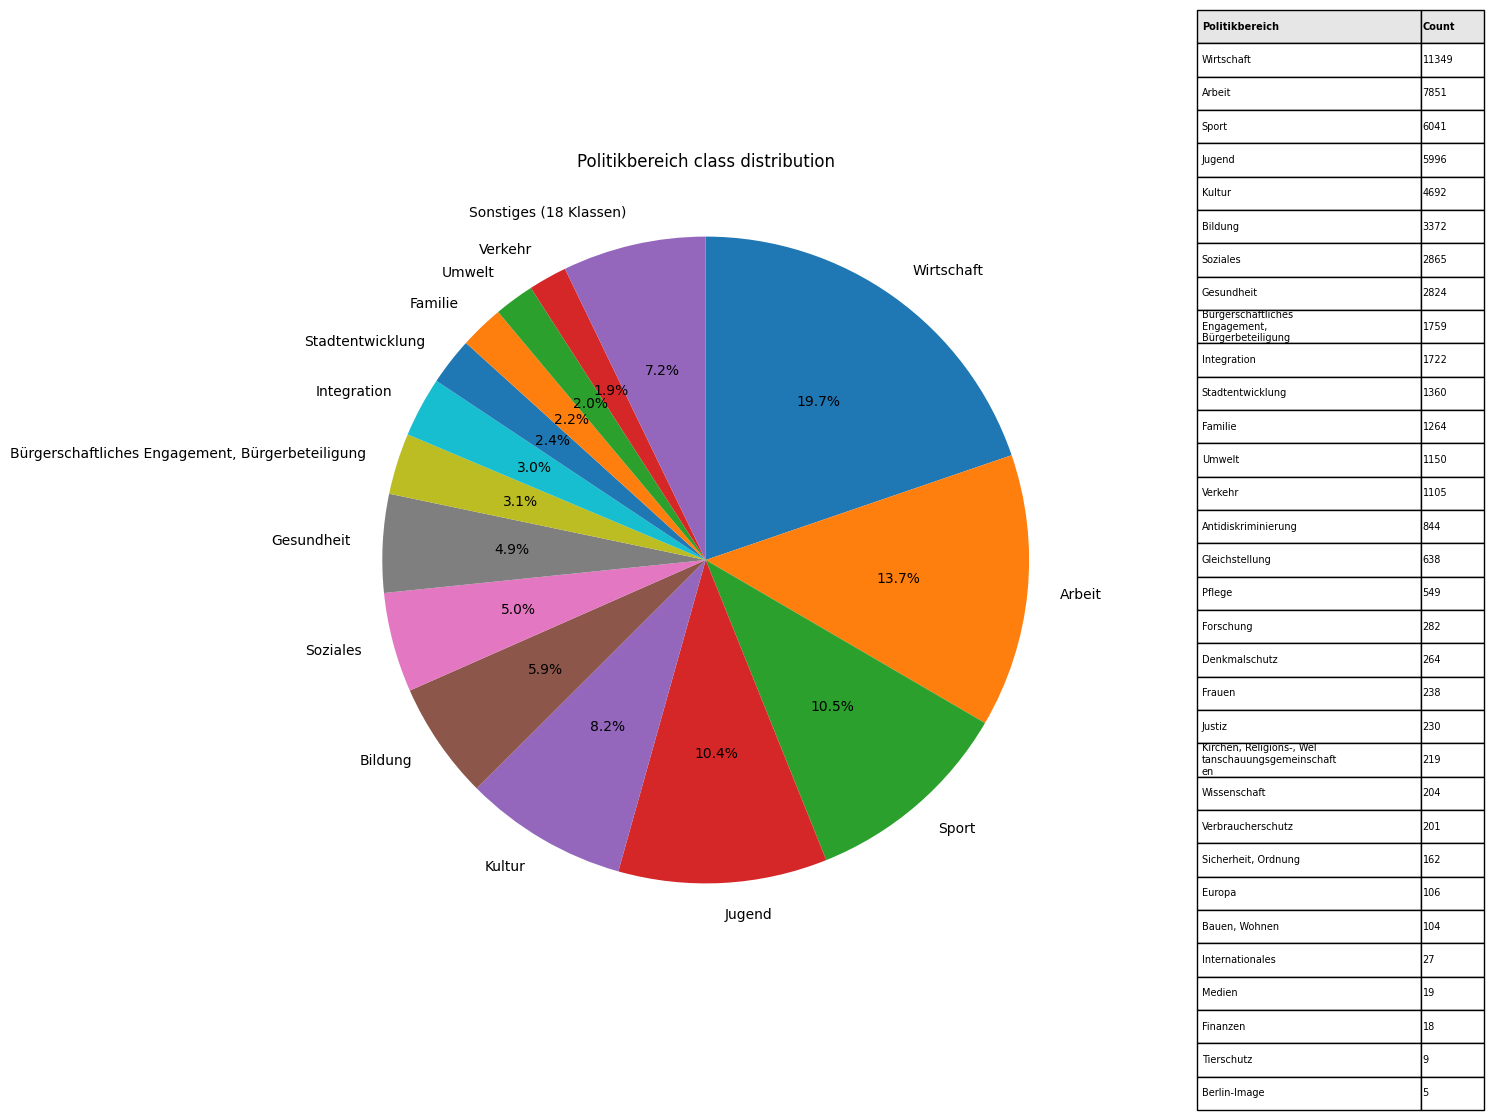

In [879]:
import textwrap
import matplotlib.pyplot as plt

# count how many classes are in the column
num_classes = df["politikbereich"].nunique()

# count how many values are in each class and normalize the counts
counts = df["politikbereich"].value_counts()
normalized_counts = df["politikbereich"].value_counts(normalize=True)
display(f"Anzahl der Klassen: {num_classes}")
# display(counts.to_frame('count'))
# display(normalized_counts.to_frame('normalized_count'))

# pie chart of the class distribution
plt.figure(figsize=(10, 10))

# Pie chart 데이터
filtered_counts = normalized_counts[normalized_counts >= 0.019]
other_counts = normalized_counts[normalized_counts < 0.019]

final_counts = pd.concat(
    [
        filtered_counts,
        pd.Series({f"Sonstiges ({len(other_counts)} Klassen)": other_counts.sum()}),
    ]
)

# 표 데이터
table_data = counts.to_frame("Count").reset_index()
table_data.columns = ["Politikbereich", "Count"]

# 긴 클래스명 줄바꿈
table_data["Politikbereich"] = table_data["Politikbereich"].apply(
    lambda value: "\n".join(textwrap.wrap(str(value), width=24))
)

# Pie 영역을 크게, 표 영역을 작게 설정
fig, (ax_pie, ax_table) = plt.subplots(
    1, 2, figsize=(16, 10), gridspec_kw={"width_ratios": [4.5, 1.5], "wspace": 0.05}
)

# Pie chart
ax_pie.pie(
    final_counts.values,
    labels=final_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    radius=1.05,
)
ax_pie.set_title("Politikbereich class distribution")

# 표
ax_table.axis("off")

table = ax_table.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.78, 0.22],  # 이름 열은 넓게, Count 열은 좁게
)

# 글자와 셀 크기 축소
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(0.95, 2)

# 셀 안에서 글자가 잘리지 않도록 설정
for (row, col), cell in table.get_celld().items():
    cell.get_text().set_wrap(True)
    cell.PAD = 0.02

    # 헤더 스타일
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#E6E6E6")

plt.show()

Nach der Bereinigung und Neuordnung enthält die Zielvariable insgesamt **32 Klassen**. Die Klassenverteilung bleibt jedoch weiterhin stark unausgewogen. Häufige Klassen wie `Wirtschaft` haben sehr viele Einträge, während sehr kleine Klassen wie `Berlin-Image` nur wenige Beobachtungen enthalten.

Diese Klassenunverteilung wird später bei der Modellbewertung berücksichtigt, insbesondere durch Macro-F1, Balanced Accuracy und klassenbezogene Metriken.

## 2.3. Standardisierung der Anschrift durch Google Geocoding API

Eine vollständige manuelle Standardisierung sämtlicher Adressdaten wäre jedoch weder realistisch noch effizient, da dafür jeder Einzelfall separat geprüft werden müsste. Daher werden die Adressen mithilfe einer Maps-API automatisiert gesucht, überprüft und in ein einheitliches Format überführt.

In [880]:
import os
import time

import pandas as pd
import requests
from IPython.display import display
from tqdm.auto import tqdm
from dotenv import load_dotenv

load_dotenv()

GOOGLE_MAPS_API_KEY = os.environ["GOOGLE_MAPS_API_KEY"]
GEOCODING_URL = "https://maps.googleapis.com/maps/api/geocode/json"

# Zum Testen zunächst eine begrenzte Anzahl verwenden.
# Für alle Anschriften kann der Wert später auf None gesetzt werden.
MAX_REQUESTS = 100

In [881]:
def get_google_address(address):
    """
    Sucht eine Anschrift mit der Google Maps Geocoding API
    und gibt die standardisierte Anschrift zurück.
    """
    if pd.isna(address) or not str(address).strip():
        return {
            "anschrift": address,
            "anschrift_google": pd.NA,
            "google_status": "EMPTY",
            "partial_match": pd.NA,
        }

    try:
        response = requests.get(
            GEOCODING_URL,
            params={
                "address": address,
                "key": GOOGLE_MAPS_API_KEY,
                "language": "de",
                "region": "de",
                "components": "country:DE",
            },
            timeout=20,
        )

        response.raise_for_status()
        data = response.json()

    except requests.RequestException as error:
        return {
            "anschrift": address,
            "anschrift_google": pd.NA,
            "google_status": f"REQUEST_ERROR: {error}",
            "partial_match": pd.NA,
        }

    if data.get("status") != "OK" or not data.get("results"):
        return {
            "anschrift": address,
            "anschrift_google": pd.NA,
            "google_status": data.get("status"),
            "partial_match": pd.NA,
        }

    result = data["results"][0]

    return {
        "anschrift": address,
        "anschrift_google": result.get("formatted_address"),
        "google_status": data.get("status"),
        "partial_match": result.get("partial_match", False),
    }

In [882]:
# Bereits normalisierte Anschriften beibehalten
df_normalized["anschrift_vor_google"] = df_normalized["anschrift_normalized"]

In [883]:
# Nur eindeutige Anschriften an Google senden,
# um unnötige und kostenpflichtige API-Anfragen zu vermeiden.
unique_addresses = (
    df_normalized["anschrift_vor_google"].dropna().astype(str).drop_duplicates()
)

print(
    "Anzahl eindeutiger Anschriften vor der Google-Suche:",
    len(unique_addresses),
)

Anzahl eindeutiger Anschriften vor der Google-Suche: 11091


In [884]:
# from tqdm.auto import tqdm
# import time

# google_results = []

# for address in tqdm(unique_addresses):
#     google_results.append(get_google_address(address))

#     # Kurze Pause zwischen den Anfragen
#     time.sleep(0.05)

# google_addresses = pd.DataFrame(google_results)

# google_addresses = google_addresses.rename(
#     columns={
#         "anschrift": "anschrift_vor_google",
#         "anschrift_google": "anschrift_google",
#     }
# )

# display(google_addresses.head())

In [885]:
# google_addresses.to_csv(
#     project_root / "data" / "processed" / "google_addresses.csv",
#     index=False,
#     sep=";",
#     encoding="utf-8",
# )

google_addresses = pd.read_csv(
    project_root / "data" / "processed" / "google_addresses.csv",
    sep=";",
    encoding="utf-8",
)

In [886]:
# Für jede Anschrift nur ein Google-Ergebnis verwenden.
# Dadurch wird eine unbeabsichtigte Vermehrung der Zeilen verhindert.
google_lookup = google_addresses.drop_duplicates(
    subset="anschrift_vor_google",
    keep="last",
).set_index("anschrift_vor_google")

# Google-Ergebnisse anhand der normalisierten Anschrift zuordnen.
# Vorhandene Spalten werden dabei kontrolliert überschrieben.
df_normalized["anschrift_google"] = df_normalized["anschrift_vor_google"].map(
    google_lookup["anschrift_google"]
)

df_normalized["google_status"] = df_normalized["anschrift_vor_google"].map(
    google_lookup["google_status"]
)

df_normalized["partial_match"] = df_normalized["anschrift_vor_google"].map(
    google_lookup["partial_match"]
)

In [887]:
# Nur eindeutige und erfolgreiche Google-Treffer verwenden.
# Fehlende Werte und Teiltreffer werden automatisch ausgeschlossen.
valid_google_result = (
    df_normalized["google_status"].eq("OK")
    & df_normalized["anschrift_google"].notna()
    & df_normalized["partial_match"].eq(False)
)

# Standardmäßig wird die bisher normalisierte Anschrift beibehalten.
df_normalized["anschrift_google_standardised"] = df_normalized["anschrift_vor_google"]

# Nur gültige Google-Ergebnisse übernehmen.
df_normalized.loc[
    valid_google_result,
    "anschrift_google_standardised",
] = df_normalized.loc[
    valid_google_result,
    "anschrift_google",
]

print("Anzahl der Datensätze:", len(df_normalized))
print(
    "Anzahl erfolgreicher Google-Zuordnungen:",
    valid_google_result.sum(),
)

display(
    df_normalized.loc[
        valid_google_result,
        [
            "anschrift_original",
            "anschrift_vor_google",
            "anschrift_google_standardised",
            "google_status",
            "partial_match",
        ],
    ].head(10)
)

Anzahl der Datensätze: 57469
Anzahl erfolgreicher Google-Zuordnungen: 55831


,anschrift_original,anschrift_vor_google,anschrift_google_standardised,google_status,partial_match
0,"gesslerstrasse 11, 10829 berlin","gesslerstrasse 11, 10829 berlin","Geßlerstraße 11, 10829 Berlin-Bezirk Tempelhof...",OK,False
1,"pirolstrasse 82, 12683 berlin","pirolstrasse 82, 12683 berlin","Pirolstraße 82, 12683 Berlin-Bezirk Marzahn-He...",OK,False
2,"hansastrasse 190, 13088 berlin","hansastrasse 190, 13088 berlin","Hansastraße 190, 13088 Berlin, Deutschland",OK,False
3,"am oder-spree-kanal 23d, 12527 berlin","am oder-spree-kanal 23d, 12527 berlin","Am Oder-Spree-Kanal 23D, 12527 Berlin-Bezirk T...",OK,False
4,"possweg 45, 14163 berlin","possweg 45, 14163 berlin","Poßweg 45, 14163 Berlin-Bezirk Steglitz-Zehlen...",OK,False
5,"possweg 45 c/o nkmg, 14163 berlin","possweg 45 c/o nkmg, 14163 berlin","Poßweg 45, 14163 Berlin-Bezirk Steglitz-Zehlen...",OK,False
6,"possweg 45, 14163 berlin","possweg 45, 14163 berlin","Poßweg 45, 14163 Berlin-Bezirk Steglitz-Zehlen...",OK,False
7,"schönwalder allee 26/45, 13587 berlin","schönwalder allee 26/45, 13587 berlin","Schönwalder Allee 26/45, 13587 Berlin, Deutsch...",OK,False
8,"hermannstrasse 29, 14163 berlin","hermannstrasse 29, 14163 berlin","Hermannstraße 29, 14163 Berlin-Bezirk Steglitz...",OK,False
9,"gesslerstrasse 11, 10829 berlin","gesslerstrasse 11, 10829 berlin","Geßlerstraße 11, 10829 Berlin-Bezirk Tempelhof...",OK,False


In [888]:
changed_addresses_google = (
    df_normalized.loc[
        valid_google_result
        & df_normalized["anschrift_vor_google"]
        .astype("string")
        .ne(df_normalized["anschrift_google_standardised"].astype("string")),
        [
            "anschrift_original",
            "anschrift_vor_google",
            "anschrift_google_standardised",
        ],
    ]
    .drop_duplicates("anschrift_vor_google")
    .reset_index(drop=True)
)

print(
    "Anzahl eindeutiger, durch Google veränderter Anschriften:",
    len(changed_addresses_google),
)
display(changed_addresses_google.head(10))

Anzahl eindeutiger, durch Google veränderter Anschriften: 10402


,anschrift_original,anschrift_vor_google,anschrift_google_standardised
0,"gesslerstrasse 11, 10829 berlin","gesslerstrasse 11, 10829 berlin","Geßlerstraße 11, 10829 Berlin-Bezirk Tempelhof..."
1,"pirolstrasse 82, 12683 berlin","pirolstrasse 82, 12683 berlin","Pirolstraße 82, 12683 Berlin-Bezirk Marzahn-He..."
2,"hansastrasse 190, 13088 berlin","hansastrasse 190, 13088 berlin","Hansastraße 190, 13088 Berlin, Deutschland"
3,"am oder-spree-kanal 23d, 12527 berlin","am oder-spree-kanal 23d, 12527 berlin","Am Oder-Spree-Kanal 23D, 12527 Berlin-Bezirk T..."
4,"possweg 45, 14163 berlin","possweg 45, 14163 berlin","Poßweg 45, 14163 Berlin-Bezirk Steglitz-Zehlen..."
5,"possweg 45 c/o nkmg, 14163 berlin","possweg 45 c/o nkmg, 14163 berlin","Poßweg 45, 14163 Berlin-Bezirk Steglitz-Zehlen..."
6,"schönwalder allee 26/45, 13587 berlin","schönwalder allee 26/45, 13587 berlin","Schönwalder Allee 26/45, 13587 Berlin, Deutsch..."
7,"hermannstrasse 29, 14163 berlin","hermannstrasse 29, 14163 berlin","Hermannstraße 29, 14163 Berlin-Bezirk Steglitz..."
8,"sokratesweg 85, 10318 berlin","sokratesweg 85, 10318 berlin","Sokratesweg 85, 10318 Berlin-Bezirk Lichtenber..."
9,"reinhold-würth-strasse 12-17, 74653 künzelau","reinhold-würth-strasse 12-17, 74653 künzelau","Reinhold-Würth-Straße 12-17, 74653 Künzelsau-G..."


In [889]:
# Prüfen, ob mehrere unterschiedliche bisherige Anschriften
# derselben Google-Anschrift zugeordnet wurden.
merged_addresses_google = (
    df_normalized.loc[valid_google_result]
    .dropna(
        subset=[
            "anschrift_vor_google",
            "anschrift_google_standardised",
        ]
    )
    .groupby("anschrift_google_standardised")["anschrift_vor_google"]
    .agg(
        Anzahl_Originalvarianten="nunique",
        Originalvarianten=lambda values: sorted(values.unique()),
    )
    .reset_index()
)

# Nur Gruppen mit mindestens zwei unterschiedlichen
# Anschriften vor der Google-Standardisierung auswählen.
merged_addresses_google = (
    merged_addresses_google[merged_addresses_google["Anzahl_Originalvarianten"] > 1]
    .sort_values(
        "Anzahl_Originalvarianten",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Anzahl zusätzlich durch Google " "zusammengeführter Adressgruppen:",
    len(merged_addresses_google),
)

Anzahl zusätzlich durch Google zusammengeführter Adressgruppen: 1116


In [890]:
if not merged_addresses_google.empty:
    example_address_google = merged_addresses_google.iloc[0]

    print(
        "Google-standardisierte Anschrift:",
        example_address_google["anschrift_google_standardised"],
    )

    print(
        "Anzahl der zusammengeführten Varianten:",
        example_address_google["Anzahl_Originalvarianten"],
    )

    address_variants_google = pd.DataFrame(
        {"Anschrift_vor_Google": example_address_google["Originalvarianten"]}
    )

    display(address_variants_google)

else:
    print("Google hat keine zusätzlichen " "Adressvarianten zusammengeführt.")

Google-standardisierte Anschrift: Obentrautstraße 16/18, 10963 Berlin-Bezirk Friedrichshain-Kreuzberg, Deutschland
Anzahl der zusammengeführten Varianten: 16


,Anschrift_vor_Google
0,"obentrautstrasse 16 - 18, 10119 berlin"
1,"obentrautstrasse 16 - 18, 10318 berlin"
2,"obentrautstrasse 16 - 18, 10557 berlin"
3,"obentrautstrasse 16 - 18, 10719 berlin"
4,"obentrautstrasse 16 - 18, 10963 berlin"
5,"obentrautstrasse 16 - 18, 10969 berlin"
6,"obentrautstrasse 16 - 18, 10997 berlin"
7,"obentrautstrasse 16 - 18, 12277 berlin"
8,"obentrautstrasse 16 - 18, 12679 berlin"
9,"obentrautstrasse 16 - 18, 12681 berlin"


In [891]:
unique_original = df_normalized["anschrift_original"].dropna().nunique()

unique_after_normalization = df_normalized["anschrift_vor_google"].dropna().nunique()

unique_after_google = (
    df_normalized["anschrift_google_standardised"].dropna().nunique()
)

comparison = pd.DataFrame(
    {
        "Verarbeitungsschritt": [
            "Originaldaten",
            "Eigene Normalisierung",
            "Normalisierung + Google-Maps-Standardisierung",
        ],
        "Eindeutige_Anschriften": [
            unique_original,
            unique_after_normalization,
            unique_after_google,
        ],
    }
)

comparison["Reduktion_zum_Vorschritt"] = (
    comparison["Eindeutige_Anschriften"]
    .shift(1)
    .sub(comparison["Eindeutige_Anschriften"])
    .fillna(0)
    .astype(int)
)

comparison["Reduktion_zum_Vorschritt_%"] = (
    comparison["Reduktion_zum_Vorschritt"]
    .div(comparison["Eindeutige_Anschriften"].shift(1))
    .mul(100)
    .fillna(0)
    .round(2)
)

display(comparison)

,Verarbeitungsschritt,Eindeutige_Anschriften,Reduktion_zum_Vorschritt,Reduktion_zum_Vorschritt_%
0,Originaldaten,11160,0,0.00
1,Eigene Normalisierung,11091,69,0.62
2,Normalisierung + Google-Maps-Standardisierung,9711,1380,12.44


In [892]:
# Für einen fairen Vergleich werden nur Zeilen verwendet,
# für die beide Anschriftversionen vorhanden sind.
comparison_df = (
    df_normalized[
        [
            "empfaengerid",
            "jahr",
            "anschrift_vor_google",
            "anschrift_google_standardised",
        ]
    ]
    .dropna()
    .copy()
)

# Nur die unmittelbar von der Adressstandardisierung
# betroffenen Beziehungen untersuchen.
relationships = [
    (
        "empfaengerid → anschrift",
        ["empfaengerid"],
        "anschrift",
    ),
    (
        "empfaengerid + jahr → anschrift",
        ["empfaengerid", "jahr"],
        "anschrift",
    ),
]

comparison_results = []

for address_version, address_column in [
    ("Vor Google", "anschrift_vor_google"),
    (
        "Nach Google",
        "anschrift_google_standardised",
    ),
]:
    current_df = comparison_df[
        [
            "empfaengerid",
            "jahr",
            address_column,
        ]
    ].rename(columns={address_column: "anschrift"})

    for relationship, group_columns, target_column in relationships:
        score = dependency_score(
            current_df,
            group_columns,
            target_column,
        )

        comparison_results.append(
            {
                "Beziehung": relationship,
                "Datenstand": address_version,
                "Übereinstimmungsrate_%": round(
                    score * 100,
                    2,
                ),
            }
        )

scores_comparison = (
    pd.DataFrame(comparison_results)
    .pivot(
        index="Beziehung",
        columns="Datenstand",
        values="Übereinstimmungsrate_%",
    )
    .reset_index()
)

scores_comparison["Veränderung_in_Prozentpunkten"] = (
    scores_comparison["Nach Google"] - scores_comparison["Vor Google"]
).round(2)

print("Vergleich der Adressenkonsistenz vor und nach der Google-Maps-Standardisierung:")
display(scores_comparison)

Vergleich der Adressenkonsistenz vor und nach der Google-Maps-Standardisierung:


Datenstand,Beziehung,Nach Google,Vor Google,Veränderung_in_Prozentpunkten
0,empfaengerid + jahr → anschrift,95.44,92.92,2.52
1,empfaengerid → anschrift,90.44,86.41,4.03


## 2.4. Normalisierung und Standardisierung der Namen

Über die [Transparenzdatenbank des Landes Berlin](https://transparenzdatenbank.berlin.de/oberflaeche/?anwender_id=5&dateiname=organisation_suche_transparenz.cfm) lässt sich anhand der Empfänger-ID die offizielle Bezeichnung einer Organisation ermitteln. Hierzu wurden die öffentlich zugänglichen Organisationsnamen und die zugehörigen Empfänger-IDs automatisiert ausgelesen und anschließend in einer CSV-Datei für die weitere Datenverarbeitung gespeichert.

In [893]:
from pathlib import Path

import pandas as pd
from IPython.display import display

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

transparency_path = (
    project_root / "data" / "raw" / "transparenzdatenbank_organisationen.csv"
)

df_transparency = pd.read_csv(
    transparency_path,
    encoding="utf-8",
)

print("Anzahl der Organisationen:", len(df_transparency))
display(df_transparency.head())

Anzahl der Organisationen: 23500


,name,empfaengerid,letzte_datenaktualisierung,transparenz_detail_id,detail_url,source_page
0,!K7 Records GmbH,hrb_060789,14.10.2019,C350B31290A88A003D5008F8FAFF16FC,https://transparenzdatenbank.berlin.de/oberfla...,587
1,!KF - Institut für künstlerische Forschung,vr_028872,14.10.2022,C3B6BC3A70A441407DB36361B8B16D95,https://transparenzdatenbank.berlin.de/oberfla...,602
2,!Respect e. V.,nr_101426,18.10.2024,121A1DC542713D98355203221BD3A4BA,https://transparenzdatenbank.berlin.de/oberfla...,885
3,""" E S B E R "" Verwaltungsgesellschaft mit besc...",hrb_001875,NaN,21C8DA8994AE5FC56CD263DA0FDBD521,https://transparenzdatenbank.berlin.de/oberfla...,343
4,"""Berliner Jugendclub"" - Stätte der Begegnung -",vr_003027,09.03.2020,8CD56A3AA26704E388A946011EB29ADE,https://transparenzdatenbank.berlin.de/oberfla...,120


Die ursprünglichen Werte in den Spalten `name` und `empfaengerid` werden zunächst beibehalten. Fehlende Empfänger-IDs werden nur dann anhand der Kombination aus standardisiertem Namen und Google-standardisierter Anschrift ergänzt, wenn diese Kombination in den vorhandenen Daten mehrfach und eindeutig derselben ID zugeordnet ist.

Anschließend wird für jede Empfänger-ID der häufigste Name als kanonische Bezeichnung bestimmt. Weichen bei einem Datensatz sowohl der Name als auch die Anschrift vom typischen Muster der ID ab, wird dieser nicht automatisch geändert, sondern zur manuellen Prüfung markiert. Dadurch sollen fehlerhafte Zusammenführungen unterschiedlicher Organisationen vermieden werden.

In [894]:
import re
import numpy as np
import pandas as pd
from IPython.display import display

#### Transparenzdaten normalisieren

In [895]:
# Normalisieren der Spalten "name" und "empfaengerid"
# in den Daten der Transparenzdatenbank
using_columns_transparency = [
    "name",
    "empfaengerid",
]

df_transparency_original = (
    df_transparency[
        using_columns_transparency
    ]
    .copy()
)

df_transparency_normalized = (
    df_transparency[
        using_columns_transparency
    ]
    .copy()
)

df_transparency_normalized["name"] = (
    df_transparency_normalized["name"]
    .apply(normalize_text)
)

display(df_transparency_normalized.head())

,name,empfaengerid
0,!k7 records gmbh,hrb_060789
1,!kf - institut für künstlerische forschung,vr_028872
2,!respect e. v.,nr_101426
3,""" e s b e r "" verwaltungsgesellschaft mit besc...",hrb_001875
4,"""berliner jugendclub"" - stätte der begegnung -",vr_003027


#### Referenztabelle mit offiziellen Organisationsnamen

In [896]:
# Originale und normalisierte Organisationsnamen
# in einer Referenztabelle zusammenführen
transparency_reference = pd.DataFrame(
    {
        "entity_id_official":
            df_transparency_original[
                "empfaengerid"
            ],
        "name_official":
            df_transparency_original["name"],
        "name_official_normalized":
            df_transparency_normalized["name"],
    }
)

# Datensätze ohne Empfänger-ID können nicht
# als eindeutige Referenz verwendet werden.
transparency_reference = (
    transparency_reference
    .dropna(
        subset=[
            "entity_id_official",
            "name_official_normalized",
        ]
    )
    .drop_duplicates(
        subset="entity_id_official",
        keep="last",
    )
    .reset_index(drop=True)
)

print(
    "Anzahl der Organisationen "
    "in der Referenztabelle:",
    len(transparency_reference),
)

display(transparency_reference.head())

Anzahl der Organisationen in der Referenztabelle: 23500


,entity_id_official,name_official,name_official_normalized
0,hrb_060789,!K7 Records GmbH,!k7 records gmbh
1,vr_028872,!KF - Institut für künstlerische Forschung,!kf - institut für künstlerische forschung
2,nr_101426,!Respect e. V.,!respect e. v.
3,hrb_001875,""" E S B E R "" Verwaltungsgesellschaft mit besc...",""" e s b e r "" verwaltungsgesellschaft mit besc..."
4,vr_003027,"""Berliner Jugendclub"" - Stätte der Begegnung -","""berliner jugendclub"" - stätte der begegnung -"


In [897]:
# Die bereits normalisierten Daten werden kopiert.
# Vorhandene Werte werden nicht überschrieben.
df_entity_cleaned = df_normalized.copy()

df_entity_cleaned["name_normalized"] = (
    df_entity_cleaned["name"]
)

df_entity_cleaned["empfaengerid_original"] = (
    df_entity_cleaned["empfaengerid"]
)

# Offizielle Organisationsdaten anhand
# der vorhandenen Empfänger-ID ergänzen
df_entity_cleaned = df_entity_cleaned.merge(
    transparency_reference,
    left_on="empfaengerid_original",
    right_on="entity_id_official",
    how="left",
    validate="many_to_one",
)

df_entity_cleaned["official_id_found"] = (
    df_entity_cleaned["entity_id_official"]
    .notna()
)

#### Vergleichsnamen vorbereiten

Für den Vergleich werden Satzzeichen und Rechtsformen entfernt. Die offiziellen Namen selbst bleiben unverändert.

In [898]:
# Satzzeichen zuerst vereinheitlichen, damit beispielsweise
# "e. V.", "e.V." und "e v" anschließend gleich behandelt werden.
# Umfassende deutsche Rechtsformbezeichnungen und gebräuchliche
# Registerabkürzungen. Längere zusammengesetzte Formen stehen zuerst.
legal_form_pattern = (
    r"\b(?:"
    r"(?:gmbh|ggmbh|ug|gug|ag|se)\s+(?:und\s+)?co\s+"
    r"(?:kg|kgaa)|"
    r"part(?:nerschaftsgesellschaft|nerschaft|g)?\s+mbb|"
    r"partnerschaftsgesellschaft\s+mit\s+beschränkter\s+berufshaftung|"
    r"unternehmergesellschaft\s+haftungsbeschränkt|"
    r"gemeinnützige\s+unternehmergesellschaft\s+haftungsbeschränkt|"
    r"gemeinnützige\s+gesellschaft\s+mit\s+beschränkter\s+haftung|"
    r"gesellschaft\s+mit\s+beschränkter\s+haftung|"
    r"aktiengesellschaft|"
    r"kommanditgesellschaft\s+auf\s+aktien|"
    r"kommanditgesellschaft|offene\s+handelsgesellschaft|"
    r"gesellschaft\s+bürgerlichen\s+rechts|"
    r"eingetragene\s+gesellschaft\s+bürgerlichen\s+rechts|"
    r"eingetragene\s+genossenschaft|"
    r"europäische\s+wirtschaftliche\s+interessenvereinigung|"
    r"europäische\s+genossenschaft|societas\s+europaea|"
    r"versicherungsverein\s+auf\s+gegenseitigkeit|"
    r"pensionsfondsverein\s+auf\s+gegenseitigkeit|"
    r"eingetragener\s+verein|rechtsfähiger\s+verein|"
    r"eingetragener\s+kaufmann|eingetragene\s+kauffrau|"
    r"einzelkaufmann|einzelkauffrau|"
    r"stiftung\s+(?:des\s+)?(?:bürgerlichen|öffentlichen)\s+rechts|"
    r"(?:anstalt|körperschaft)\s+des\s+öffentlichen\s+rechts|"
    r"eigenbetrieb|kommunalunternehmen|zweckverband|"
    r"ggmbh|gmbh|gug|ug|mbh|kgaa|ohg|egbr|gbr|"
    r"ewiv|vvag|pvag|partg|mbb|sce|se|ag|kg|"
    r"e\s*g|e\s*k|e\s*v|"
    r"adör|aör|kdör|kör"
    r")\b"
)

df_entity_cleaned["name_comparison"] = (
    df_entity_cleaned["name_normalized"]
    .astype("string")
    .str.replace(r"[^\wäöüß]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(legal_form_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_entity_cleaned["official_name_comparison"] = (
    df_entity_cleaned["name_official_normalized"]
    .astype("string")
    .str.replace(r"[^\wäöüß]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(legal_form_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Für deutsche Komposita wird zusätzlich eine Vergleichsvariante
# gebildet, in der Bindestriche zwischen Buchstaben entfernt werden.
# Die ursprünglichen Vergleichsspalten bleiben dabei unverändert.
df_entity_cleaned["name_comparison_compact"] = (
    df_entity_cleaned["name_normalized"]
    .astype("string")
    .str.replace(
        r"(?<=[a-zäöüß])[-‐‑–](?=[a-zäöüß])",
        "",
        regex=True,
    )
    .str.replace(r"[^\wäöüß]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(legal_form_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_entity_cleaned["official_name_comparison_compact"] = (
    df_entity_cleaned["name_official_normalized"]
    .astype("string")
    .str.replace(
        r"(?<=[a-zäöüß])[-‐‑–](?=[a-zäöüß])",
        "",
        regex=True,
    )
    .str.replace(r"[^\wäöüß]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(legal_form_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

#### Exakte Übereinstimmung und Namensbestandteile

Die exakte Übereinstimmung besitzt die höchste Priorität. Danach wird geprüft, ob ein vollständiger Name als Wortfolge im jeweils anderen Namen enthalten ist.

In [899]:
df_entity_cleaned["name_exact_match"] = (
    df_entity_cleaned["name_normalized"].eq(
        df_entity_cleaned["name_official_normalized"]
    )
    & df_entity_cleaned["name_official_normalized"].notna()
)

current_padded = (
    " "
    + df_entity_cleaned["name_comparison"].fillna("")
    + " "
)
official_padded = (
    " "
    + df_entity_cleaned["official_name_comparison"].fillna("")
    + " "
)

# Durch die Leerzeichen werden zufällige Treffer innerhalb
# eines längeren Wortes vermieden.
df_entity_cleaned["name_containment_match"] = [
    (
        current_name in official_name
        or official_name in current_name
    )
    if (
        len(current_name.strip()) >= 4
        and len(official_name.strip()) >= 4
    )
    else False
    for current_name, official_name in zip(
        current_padded,
        official_padded,
    )
]

#### Ergänzende Namensähnlichkeiten

RapidFuzz berücksichtigt abweichende Wortreihenfolgen und zusätzliche Namensbestandteile. Character-n-Gramme erfassen insbesondere Tippfehler, Bindestriche und kleinere Schreibvarianten.

In [900]:
from rapidfuzz import fuzz


df_entity_cleaned["rapidfuzz_wratio"] = [
    fuzz.WRatio(current_name, official_name) / 100
    if (
        pd.notna(current_name)
        and pd.notna(official_name)
    )
    else np.nan
    for current_name, official_name in zip(
        df_entity_cleaned["name_comparison"],
        df_entity_cleaned["official_name_comparison"],
    )
]

df_entity_cleaned["rapidfuzz_token_set"] = [
    fuzz.token_set_ratio(current_name, official_name) / 100
    if (
        pd.notna(current_name)
        and pd.notna(official_name)
    )
    else np.nan
    for current_name, official_name in zip(
        df_entity_cleaned["name_comparison"],
        df_entity_cleaned["official_name_comparison"],
    )
]

compact_token_set = [
    fuzz.token_set_ratio(current_name, official_name) / 100
    if pd.notna(current_name) and pd.notna(official_name)
    else np.nan
    for current_name, official_name in zip(
        df_entity_cleaned["name_comparison_compact"],
        df_entity_cleaned["official_name_comparison_compact"],
    )
]

# Für die weitere Bewertung wird jeweils die stärkere
# der beiden Token-Darstellungen verwendet.
df_entity_cleaned["rapidfuzz_token_set"] = np.fmax(
    df_entity_cleaned["rapidfuzz_token_set"],
    compact_token_set,
)

token_coverage = []

for current_name, official_name in zip(
    df_entity_cleaned["name_comparison"],
    df_entity_cleaned["official_name_comparison"],
):
    if pd.isna(current_name) or pd.isna(official_name):
        token_coverage.append(np.nan)
        continue

    current_tokens = set(str(current_name).split())
    official_tokens = set(str(official_name).split())

    token_coverage.append(
        len(current_tokens & official_tokens) / len(official_tokens)
        if official_tokens
        else np.nan
    )

df_entity_cleaned["official_token_coverage"] = token_coverage

compact_token_coverage = []

for current_name, official_name in zip(
    df_entity_cleaned["name_comparison_compact"],
    df_entity_cleaned["official_name_comparison_compact"],
):
    if pd.isna(current_name) or pd.isna(official_name):
        compact_token_coverage.append(np.nan)
        continue

    current_tokens = set(str(current_name).split())
    official_tokens = set(str(official_name).split())

    compact_token_coverage.append(
        len(current_tokens & official_tokens) / len(official_tokens)
        if official_tokens
        else np.nan
    )

df_entity_cleaned["official_token_coverage"] = np.fmax(
    df_entity_cleaned["official_token_coverage"],
    compact_token_coverage,
)


def fuzzy_official_token_coverage(
    current_name,
    official_name,
    token_threshold=85,
):
    """Berechnet die fehlertolerante Abdeckung des offiziellen Namens."""
    if pd.isna(current_name) or pd.isna(official_name):
        return np.nan

    current_tokens = str(current_name).split()
    official_tokens = str(official_name).split()

    if not current_tokens or not official_tokens:
        return np.nan

    matched_tokens = sum(
        max(
            fuzz.ratio(official_token, current_token)
            for current_token in current_tokens
        ) >= token_threshold
        for official_token in official_tokens
    )

    return matched_tokens / len(official_tokens)


df_entity_cleaned["fuzzy_official_token_coverage"] = [
    fuzzy_official_token_coverage(
        current_name,
        official_name,
    )
    for current_name, official_name in zip(
        df_entity_cleaned["name_comparison"],
        df_entity_cleaned["official_name_comparison"],
    )
]

compact_fuzzy_token_coverage = [
    fuzzy_official_token_coverage(
        current_name,
        official_name,
    )
    for current_name, official_name in zip(
        df_entity_cleaned["name_comparison_compact"],
        df_entity_cleaned["official_name_comparison_compact"],
    )
]

df_entity_cleaned["fuzzy_official_token_coverage"] = np.fmax(
    df_entity_cleaned["fuzzy_official_token_coverage"],
    compact_fuzzy_token_coverage,
)

In [901]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances


# Der Vektorraum wird ausschließlich mit den externen
# offiziellen Namen der Transparenzdatenbank erstellt.
official_name_corpus = (
    transparency_reference["name_official_normalized"]
    .astype("string")
    .str.replace(r"[^\wäöüß]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(legal_form_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .dropna()
    .drop_duplicates()
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=1,
    lowercase=False,
)
char_vectorizer.fit(official_name_corpus)

current_name_vectors = char_vectorizer.transform(
    df_entity_cleaned["name_comparison"].fillna("")
)
official_name_vectors = char_vectorizer.transform(
    df_entity_cleaned["official_name_comparison"].fillna("")
)

df_entity_cleaned["char_ngram_similarity"] = (
    1
    - paired_cosine_distances(
        current_name_vectors,
        official_name_vectors,
    )
)

#### Abkürzungen und Organisationseinheiten

Abkürzungen und typische Bezeichnungen von Standorten oder Einrichtungen werden als eigenständige Signale behandelt.

In [902]:
import re


german_stopwords = {
    "der", "die", "das", "den", "dem", "des",
    "für", "und", "von", "zur", "zum",
    "im", "in", "am", "an",
}
legal_form_tokens = {
    "gmbh", "ggmbh", "ag", "ug", "ev", "kg", "mbh",
}

acronym_matches = []

for current_name, official_name, official_name_original in zip(
    df_entity_cleaned["name_comparison"],
    df_entity_cleaned["official_name_comparison"],
    df_entity_cleaned["name_official"],
):
    if pd.isna(current_name) or pd.isna(official_name):
        acronym_matches.append(False)
        continue

    current_tokens = set(str(current_name).split())
    official_tokens = [
        token
        for token in str(official_name).split()
        if (
            token not in german_stopwords
            and token not in legal_form_tokens
            and len(token) > 1
        )
    ]
    official_acronym = "".join(
        token[0] for token in official_tokens
    )
    current_short_tokens = {
        token
        for token in current_tokens
        if 3 <= len(token) <= 5
    }
    explicit_short_tokens = {
        token.casefold()
        for token in re.findall(
            r"\b[A-ZÄÖÜ]{2,6}\b",
            str(official_name_original),
        )
    }

    acronym_matches.append(
        bool(current_short_tokens & explicit_short_tokens)
        or any(
            official_acronym.startswith(token)
            or official_acronym.endswith(token)
            for token in current_short_tokens
        )
    )

df_entity_cleaned["acronym_match"] = acronym_matches

organisation_unit_pattern = (
    r"\b("
    r"klinikum\b.*|krankenhaus\b.*|region\b.*|"
    r"standort\b.*|geschäftsstelle\b.*|"
    r"beratungsstelle\b.*|jugendhilfe\b.*|"
    r"niederlassung\b.*"
    r")$"
)

df_entity_cleaned["organisationseinheit_candidate"] = (
    df_entity_cleaned["name_normalized"]
    .astype("string")
    .str.extract(organisation_unit_pattern, expand=False)
    .str.strip(" -–,")
)

#### Eindeutige offizielle Namen für fehlende IDs

Eine fehlende Empfänger-ID wird nur ergänzt, wenn der normalisierte offizielle Name eindeutig genau einer ID zugeordnet ist.

In [903]:
official_name_groups = (
    transparency_reference
    .groupby("name_official_normalized")
    .agg(
        Anzahl_IDs=("entity_id_official", "nunique"),
        entity_id_candidate=("entity_id_official", "first"),
        official_name_candidate=(
            "name_official_normalized",
            "first",
        ),
    )
    .reset_index()
)

unique_official_names = official_name_groups.loc[
    official_name_groups["Anzahl_IDs"].eq(1)
]

official_name_to_id = unique_official_names.set_index(
    "name_official_normalized"
)["entity_id_candidate"]
official_name_to_name = unique_official_names.set_index(
    "name_official_normalized"
)["official_name_candidate"]

df_entity_cleaned["entity_id_from_exact_name"] = (
    df_entity_cleaned["name_normalized"].map(
        official_name_to_id
    )
)
df_entity_cleaned["official_name_from_exact_name"] = (
    df_entity_cleaned["name_normalized"].map(
        official_name_to_name
    )
)

#### Hierarchische Zuordnung

Die Signale werden nicht zu einem schwer erklärbaren Mittelwert zusammengefasst, sondern in einer festen Reihenfolge ausgewertet.

In [904]:
df_entity_cleaned["name_relation"] = np.select(
    [
        df_entity_cleaned["name_exact_match"],
        (
            ~df_entity_cleaned["name_exact_match"]
            & df_entity_cleaned["name_containment_match"]
            & df_entity_cleaned[
                "organisationseinheit_candidate"
            ].notna()
        ),
        (
            ~df_entity_cleaned["name_exact_match"]
            & df_entity_cleaned["name_containment_match"]
        ),
        (
            df_entity_cleaned["official_id_found"]
            & df_entity_cleaned["rapidfuzz_wratio"].ge(0.85)
            & df_entity_cleaned[
                "fuzzy_official_token_coverage"
            ].ge(0.90)
        ),
        (
            ~df_entity_cleaned["name_exact_match"]
            & ~df_entity_cleaned["name_containment_match"]
            & df_entity_cleaned["acronym_match"]
        ),
        (
            df_entity_cleaned["rapidfuzz_wratio"].ge(0.90)
            & df_entity_cleaned[
                "fuzzy_official_token_coverage"
            ].ge(0.75)
        ),
        (
            df_entity_cleaned["rapidfuzz_token_set"].ge(0.95)
            & df_entity_cleaned[
                "official_token_coverage"
            ].ge(0.75)
        ),
    ],
    [
        "exact",
        "containment_with_unit",
        "containment",
        "fuzzy_containment",
        "acronym",
        "strong_fuzzy_match",
        "official_name_with_addition",
    ],
    default="unexplained_difference",
)

# Kontextsignale werden ausschließlich aus bereits verlässlichen
# Namensankern derselben offiziellen ID abgeleitet.
trusted_anchor_relations = {
    "exact",
    "containment",
    "containment_with_unit",
    "fuzzy_containment",
}

context_address_column = next(
    (
        column
        for column in [
            "anschrift_google_standardised",
            "anschrift_normalized",
            "anschrift",
        ]
        if column in df_entity_cleaned.columns
    ),
    None,
)

df_entity_cleaned["address_anchor_match"] = False

if context_address_column is not None:
    anchor_mask = (
        df_entity_cleaned["official_id_found"]
        & df_entity_cleaned["name_relation"].isin(
            trusted_anchor_relations
        )
        & df_entity_cleaned[context_address_column].notna()
    )

    anchor_address_keys = set(
        zip(
            df_entity_cleaned.loc[
                anchor_mask,
                "entity_id_official",
            ],
            df_entity_cleaned.loc[
                anchor_mask,
                context_address_column,
            ],
        )
    )

    df_entity_cleaned["address_anchor_match"] = [
        pd.notna(entity_id)
        and pd.notna(address)
        and (entity_id, address) in anchor_address_keys
        for entity_id, address in zip(
            df_entity_cleaned["entity_id_official"],
            df_entity_cleaned[context_address_column],
        )
    ]

variant_groups = df_entity_cleaned.groupby(
    ["entity_id_official", "name_normalized"],
    dropna=False,
)
df_entity_cleaned["name_variant_count"] = (
    variant_groups["name_normalized"].transform("size")
)
df_entity_cleaned["name_variant_years"] = (
    variant_groups["jahr"].transform("nunique")
    if "jahr" in df_entity_cleaned.columns
    else 1
)

context_supported_match = (
    df_entity_cleaned["official_id_found"]
    & df_entity_cleaned["name_relation"].eq(
        "unexplained_difference"
    )
    & (
        (
            df_entity_cleaned["address_anchor_match"]
            & (
                df_entity_cleaned["rapidfuzz_wratio"].ge(0.65)
                | df_entity_cleaned["rapidfuzz_token_set"].ge(0.65)
            )
        )
        | (
            df_entity_cleaned["name_variant_count"].ge(3)
            & df_entity_cleaned["name_variant_years"].ge(2)
            & df_entity_cleaned["rapidfuzz_wratio"].ge(0.70)
        )
    )
)

df_entity_cleaned.loc[
    context_supported_match,
    "name_relation",
] = "context_supported_match"

confidence_by_relation = {
    "exact": 1.00,
    "containment_with_unit": 0.97,
    "containment": 0.95,
    "fuzzy_containment": 0.92,
    "acronym": 0.93,
    "strong_fuzzy_match": 0.90,
    "official_name_with_addition": 0.88,
    "context_supported_match": 0.87,
    "unexplained_difference": 0.30,
}

# Die ursprüngliche Empfänger-ID bleibt grundsätzlich erhalten.
df_entity_cleaned["entity_id"] = (
    df_entity_cleaned["empfaengerid_original"]
)
df_entity_cleaned["name_canonical"] = (
    df_entity_cleaned["name_normalized"]
)
df_entity_cleaned["organisationseinheit"] = pd.NA
df_entity_cleaned["match_method"] = "unmatched"
df_entity_cleaned["match_confidence"] = 0.0
df_entity_cleaned["needs_review"] = True
df_entity_cleaned["review_reason"] = "no_reliable_match"

# Eine in der Transparenzdatenbank bestätigte ID und ihr
# offizieller Name werden unabhängig von der Namensähnlichkeit übernommen.
# Die Ähnlichkeit entscheidet nur über den Prüfstatus.
verified_official_id = df_entity_cleaned["official_id_found"]

df_entity_cleaned.loc[
    verified_official_id,
    "entity_id",
] = df_entity_cleaned.loc[
    verified_official_id,
    "entity_id_official",
]
df_entity_cleaned.loc[
    verified_official_id,
    "name_canonical",
] = df_entity_cleaned.loc[
    verified_official_id,
    "name_official_normalized",
]

accepted_name_variant = (
    verified_official_id
    & df_entity_cleaned["name_relation"].ne(
        "unexplained_difference"
    )
)

df_entity_cleaned.loc[
    accepted_name_variant,
    "match_method",
] = (
    "official_id_"
    + df_entity_cleaned.loc[
        accepted_name_variant,
        "name_relation",
    ]
)
df_entity_cleaned.loc[
    accepted_name_variant,
    "match_confidence",
] = df_entity_cleaned.loc[
    accepted_name_variant,
    "name_relation",
].map(confidence_by_relation)
df_entity_cleaned.loc[
    accepted_name_variant,
    "needs_review",
] = False
df_entity_cleaned.loc[
    accepted_name_variant,
    "review_reason",
] = pd.NA

unit_match = (
    accepted_name_variant
    & df_entity_cleaned["name_relation"].eq(
        "containment_with_unit"
    )
)
df_entity_cleaned.loc[
    unit_match,
    "organisationseinheit",
] = df_entity_cleaned.loc[
    unit_match,
    "organisationseinheit_candidate",
]

In [905]:
# Fehlende IDs werden ausschließlich über einen
# eindeutigen exakten offiziellen Namen ergänzt.
exact_name_without_id = (
    df_entity_cleaned["empfaengerid_original"].isna()
    & df_entity_cleaned["entity_id_from_exact_name"].notna()
)

df_entity_cleaned.loc[
    exact_name_without_id,
    "entity_id",
] = df_entity_cleaned.loc[
    exact_name_without_id,
    "entity_id_from_exact_name",
]
df_entity_cleaned.loc[
    exact_name_without_id,
    "name_canonical",
] = df_entity_cleaned.loc[
    exact_name_without_id,
    "official_name_from_exact_name",
]
df_entity_cleaned.loc[
    exact_name_without_id,
    "match_method",
] = "exact_official_name_without_id"
df_entity_cleaned.loc[
    exact_name_without_id,
    "match_confidence",
] = 0.95
df_entity_cleaned.loc[
    exact_name_without_id,
    "needs_review",
] = False
df_entity_cleaned.loc[
    exact_name_without_id,
    "review_reason",
] = pd.NA

official_id_name_conflict = (
    df_entity_cleaned["official_id_found"]
    & df_entity_cleaned["name_relation"].eq(
        "unexplained_difference"
    )
)
df_entity_cleaned.loc[
    official_id_name_conflict,
    "match_method",
] = "official_id_name_conflict"

df_entity_cleaned.loc[
    official_id_name_conflict,
    "match_confidence",
] = 0.85

df_entity_cleaned.loc[
    official_id_name_conflict,
    "review_reason",
] = "official_id_name_conflict"

id_not_in_transparency = (
    df_entity_cleaned["empfaengerid_original"].notna()
    & ~df_entity_cleaned["official_id_found"]
)
df_entity_cleaned.loc[
    id_not_in_transparency,
    "match_method",
] = "id_not_found"
df_entity_cleaned.loc[
    id_not_in_transparency,
    "review_reason",
] = "id_not_found_in_transparency_database"

missing_id_without_match = (
    df_entity_cleaned["empfaengerid_original"].isna()
    & df_entity_cleaned["entity_id_from_exact_name"].isna()
)
df_entity_cleaned.loc[
    missing_id_without_match,
    "review_reason",
] = "missing_id_and_no_exact_official_name"

#### Ergebnisübersicht der Namenszuordnung

In [906]:
df_consistent = df_entity_cleaned.loc[
    ~df_entity_cleaned["needs_review"]
].copy()
df_review = df_entity_cleaned.loc[
    df_entity_cleaned["needs_review"]
].copy()

method_summary = (
    df_entity_cleaned
    .groupby(
        ["match_method", "needs_review"],
        dropna=False,
    )
    .size()
    .rename("Anzahl")
    .reset_index()
    .sort_values("Anzahl", ascending=False)
)
method_summary["Anteil_%"] = (
    method_summary["Anzahl"]
    .div(len(df_entity_cleaned))
    .mul(100)
    .round(2)
)

display(method_summary)

# sum of anteil% of each needs_review 
print(method_summary.groupby("needs_review")["Anteil_%"].sum())

,match_method,needs_review,Anzahl,Anteil_%
5,official_id_exact,False,43457,75.62
2,official_id_containment,False,8135,14.16
10,unmatched,True,1482,2.58
4,official_id_context_supported_match,False,1326,2.31
6,official_id_fuzzy_containment,False,834,1.45
7,official_id_name_conflict,True,828,1.44
1,official_id_acronym,False,731,1.27
9,official_id_strong_fuzzy_match,False,366,0.64
3,official_id_containment_with_unit,False,203,0.35
0,id_not_found,True,83,0.14


needs_review
False    95.84
True      4.16
Name: Anteil_%, dtype: float64


In [907]:
review_summary = (
    df_review
    .groupby("review_reason", dropna=False)
    .size()
    .rename("Anzahl")
    .reset_index()
    .sort_values("Anzahl", ascending=False)
)
review_summary["Anteil_an_Gesamtdaten_%"] = (
    review_summary["Anzahl"]
    .div(len(df_entity_cleaned))
    .mul(100)
    .round(2)
)

display(review_summary)

,review_reason,Anzahl,Anteil_an_Gesamtdaten_%
1,missing_id_and_no_exact_official_name,1482,2.58
2,official_id_name_conflict,828,1.44
0,id_not_found_in_transparency_database,83,0.14


In [908]:
df_id_not_found_review = (
    df_review[
        [
            "name_normalized",
            "name_official_normalized",
            "empfaengerid_original",
            "name_relation",
            "rapidfuzz_wratio",
            "rapidfuzz_token_set",
            "char_ngram_similarity",
            "official_token_coverage",
            "review_reason",
        ]
    ]
    .sort_values(["review_reason", "empfaengerid_original"])
    .drop_duplicates(
        subset=["empfaengerid_original"],
        keep="first",
    )
)

print(df_id_not_found_review.shape[0], "Eindeutige Datensätze mit fehlender Empfänger-ID in Transparenzdatenbank")
print("\nBeispiel:")
display(df_id_not_found_review.head(10))

355 Eindeutige Datensätze mit fehlender Empfänger-ID in Transparenzdatenbank

Beispiel:


,name_normalized,name_official_normalized,empfaengerid_original,name_relation,rapidfuzz_wratio,rapidfuzz_token_set,char_ngram_similarity,official_token_coverage,review_reason
53601,verschiedene natürliche personen,NaN,0,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
23987,grün berlin gmbh,NaN,hbr_015772,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
10813,caritas krankenhilfe berlin ggmbh,NaN,hrb_ 213073,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
32297,kulturveranstaltungen des bundes in berlin gmb...,NaN,hrb_029257,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
23833,grone bildungszentren berlin ggmbh,NaN,hrb_056919,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
15656,dreieins innovative pädagogik ggmbh,NaN,hrb_094898,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
47462,"stiftung innovation in der hochschullehre,treu...",NaN,hrb_142764,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
14978,dico gesellschaft für community organizing ggmbh,NaN,hrb_147206,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
15623,drehandel gmbh,NaN,hrb_148898,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database
28879,katholische pfarrgemeinde herz jesu und st. ju...,NaN,kör_100116,unexplained_difference,NaN,NaN,0.5,NaN,id_not_found_in_transparency_database


In [909]:
official_id_conflicts = (
    df_review.loc[
        df_review["review_reason"].eq(
            "official_id_name_conflict"
        ),
        [
            "name_normalized",
            "name_official_normalized",
            "empfaengerid_original",
            "entity_id_official",
            "entity_id",
            "name_relation",
            "rapidfuzz_wratio",
            "rapidfuzz_token_set",
            "char_ngram_similarity",
            "official_token_coverage",
            "match_method",
            "match_confidence",
            "review_reason",
        ],
    ]
    .sort_values(
        [
            "empfaengerid_original",
            "name_normalized",
        ]
    )
    .drop_duplicates(
        subset=[
            "empfaengerid_original"
        ],
        keep="first",
    )
    .reset_index(drop=True)
)

display(official_id_conflicts.head(20))

,name_normalized,name_official_normalized,empfaengerid_original,entity_id_official,entity_id,name_relation,rapidfuzz_wratio,rapidfuzz_token_set,char_ngram_similarity,official_token_coverage,match_method,match_confidence,review_reason
0,kindertagesstätten nordwest eigenbetrieb von b...,"kindertagesstätten südost, eigenbetrieb von be...",eb_100004,eb_100004,eb_100004,unexplained_difference,0.891892,0.892308,6.749746e-01,0.750000,official_id_name_conflict,0.85,official_id_name_conflict
1,mietergenossen-schaft selbstbau e.g.,selbstbaugenossenschaft berlin e.g.,gnr_000424,gnr_000424,gnr_000424,unexplained_difference,0.622951,0.566667,6.157211e-01,0.000000,official_id_name_conflict,0.85,official_id_name_conflict
2,gewerbehof saarbrücker strasse eg,genossenschaft in der alten königstadtbrauerei eg,gnr_000538,gnr_000538,gnr_000538,unexplained_difference,0.368421,0.368421,1.081586e-02,0.000000,official_id_name_conflict,0.85,official_id_name_conflict
3,wbg „bremer höhe“ eg,"wohnungsbaugenossenschaft ""bremer höhe"" e. g.",gnr_000569,gnr_000569,gnr_000569,unexplained_difference,0.855000,0.846154,5.338109e-01,0.666667,official_id_name_conflict,0.85,official_id_name_conflict
4,wbg „am ostseeplatz“ eg,"wohnungsbaugenossenschaft ""am ostseeplatz"" eg",gnr_000577,gnr_000577,gnr_000577,unexplained_difference,0.855000,0.875000,6.186797e-01,0.666667,official_id_name_conflict,0.85,official_id_name_conflict
5,howoge wohnungsbaugesellschaft mbh,degewo aktiengesellschaft,hrb_001217,hrb_001217,hrb_001217,unexplained_difference,0.600000,0.222222,-2.220446e-16,0.000000,official_id_name_conflict,0.85,official_id_name_conflict
6,gewobag pb wohnen in prenzlauer berg gmbh,gewobag wohnungsbau-aktiengesellschaft berlin,hrb_003445,hrb_003445,hrb_003445,unexplained_difference,0.612903,0.612903,4.770815e-01,0.333333,official_id_name_conflict,0.85,official_id_name_conflict
7,havelländische eisenbahn ag,niederbarnimer eisenbahn-aktiengesellschaft,hrb_007522,hrb_007522,hrb_007522,unexplained_difference,0.583333,0.583333,3.482925e-01,0.500000,official_id_name_conflict,0.85,official_id_name_conflict
8,dominikus krankenhaus berlin hermsdorf,caritas-klinik dominikus berlin-reinickendorf ...,hrb_009954,hrb_009954,hrb_009954,unexplained_difference,0.595181,0.641975,4.504828e-01,0.400000,official_id_name_conflict,0.85,official_id_name_conflict
9,holzmanufaktur in kreuzberg gmbh,tischlerei holzmanufaktur in berlin gmbh,hrb_011925,hrb_011925,hrb_011925,unexplained_difference,0.734091,0.772727,6.936778e-01,0.500000,official_id_name_conflict,0.85,official_id_name_conflict


#### Finale Bereinigungsspalten definieren

In [910]:
final_columns = [
    "name_normalized",
    "name_official_normalized",
    "name_canonical",
    "organisationseinheit",
    "empfaengerid_original",
    "entity_id",
    "name_relation",
    "rapidfuzz_wratio",
    "rapidfuzz_token_set",
    "char_ngram_similarity",
    "official_token_coverage",
    "fuzzy_official_token_coverage",
    "address_anchor_match",
    "name_variant_count",
    "name_variant_years",
    "match_method",
    "match_confidence",
    "needs_review",
    "review_reason",
]

display(df_entity_cleaned[final_columns].head(20))

,name_normalized,name_official_normalized,name_canonical,organisationseinheit,empfaengerid_original,entity_id,name_relation,rapidfuzz_wratio,rapidfuzz_token_set,char_ngram_similarity,official_token_coverage,fuzzy_official_token_coverage,address_anchor_match,name_variant_count,name_variant_years,match_method,match_confidence,needs_review,review_reason
0,"""ausländer mit uns"" - verein zur förderung int...",verein zur förderung interkultureller begegnun...,verein zur förderung interkultureller begegnun...,<NA>,vr_004960,vr_004960,fuzzy_containment,0.950,1.000000,0.928653,1.000000,1.000000,True,1,1,official_id_fuzzy_containment,0.92,False,<NA>
1,» mehrsicht « jugend*kultur*bildung e. v.,» mehrsicht « jugend*kultur*bildung e. v.,» mehrsicht « jugend*kultur*bildung e. v.,<NA>,vr_038196,vr_038196,exact,1.000,1.000000,1.000000,1.000000,1.000000,True,2,2,official_id_exact,1.00,False,<NA>
2,e. v.sv preussen berlin e. v.,sportverein preussen berlin e. v.,sportverein preussen berlin e. v.,<NA>,vr_011425,vr_011425,context_supported_match,0.855,0.909091,0.734716,0.666667,0.666667,True,1,1,official_id_context_supported_match,0.87,False,<NA>
3,its training gesellschaft mit beschränkter haf...,its training gesellschaft mit beschränkter haf...,its training gesellschaft mit beschränkter haf...,<NA>,hrb_084522,hrb_084522,exact,1.000,1.000000,1.000000,1.000000,1.000000,True,2,2,official_id_exact,1.00,False,<NA>
4,it's.bb e. v.,it's.bb e. v.,it's.bb e. v.,<NA>,vr_037100,vr_037100,exact,1.000,1.000000,1.000000,1.000000,1.000000,True,3,2,official_id_exact,1.00,False,<NA>
5,it's.bb e. v.,it's.bb e. v.,it's.bb e. v.,<NA>,vr_037100,vr_037100,exact,1.000,1.000000,1.000000,1.000000,1.000000,True,3,2,official_id_exact,1.00,False,<NA>
6,it's.bb e. v.,it's.bb e. v.,it's.bb e. v.,<NA>,vr_037100,vr_037100,exact,1.000,1.000000,1.000000,1.000000,1.000000,True,3,2,official_id_exact,1.00,False,<NA>
7,johannesstift diakonie jugendhilfe,johannesstift diakonie jugendhilfe ggmbh,johannesstift diakonie jugendhilfe ggmbh,jugendhilfe,hrb_124070,hrb_124070,containment_with_unit,1.000,1.000000,1.000000,1.000000,1.000000,True,1,1,official_id_containment_with_unit,0.97,False,<NA>
8,umweltforum für aktion und zusammenarbeit e. v.,umweltforum für aktion und zusammenarbeit e. v.,umweltforum für aktion und zusammenarbeit e. v.,<NA>,vr_027417,vr_027417,exact,1.000,1.000000,1.000000,1.000000,1.000000,True,5,4,official_id_exact,1.00,False,<NA>
9,"""ausländer mit uns"" - verein zur förderung int...",verein zur förderung interkultureller begegnun...,verein zur förderung interkultureller begegnun...,<NA>,vr_004960,vr_004960,fuzzy_containment,0.950,1.000000,0.838372,1.000000,1.000000,True,1,1,official_id_fuzzy_containment,0.92,False,<NA>


#### Standardisierung des Empfängernamens

Der offizielle Name wird nur für Datensätze übernommen, deren Zuordnung keine manuelle Prüfung erfordert (`needs_review == False`). Bei unsicheren Datensätzen bleibt der bisher normalisierte Name erhalten. Dadurch werden bestätigte Namensvarianten vereinheitlicht, ohne ungeklärte Fälle automatisch zu überschreiben.

In [911]:
# Der normalisierte Ausgangsname bleibt zunächst für alle Zeilen erhalten.
df_entity_cleaned["name_standardised"] = (
    df_entity_cleaned["name_normalized"]
)

# Nur zuverlässig zugeordnete Datensätze erhalten den offiziellen Namen.
standardised_name_mask = (
    df_entity_cleaned["needs_review"].eq(False)
    & df_entity_cleaned["name_canonical"].notna()
)
df_entity_cleaned.loc[
    standardised_name_mask,
    "name_standardised",
] = df_entity_cleaned.loc[
    standardised_name_mask,
    "name_canonical",
]

# Ermitteln, bei wie vielen Zeilen sich der Name tatsächlich geändert hat.
standardised_name_changed = (
    df_entity_cleaned["name_normalized"]
    .astype("string")
    .ne(
        df_entity_cleaned["name_standardised"]
        .astype("string")
    )
    & df_entity_cleaned["name_normalized"].notna()
    & df_entity_cleaned["name_standardised"].notna()
)

original_unique_names = df_entity_cleaned[
    "name_normalized"
].nunique(dropna=True)
standardised_unique_names = df_entity_cleaned[
    "name_standardised"
].nunique(dropna=True)
merged_name_variants = (
    original_unique_names - standardised_unique_names
)

name_normalization_summary = pd.DataFrame(
    [
        {
            "column": "name",
            "original_unique": original_unique_names,
            "standardised_unique": standardised_unique_names,
            "merged_by_standardisation": merged_name_variants,
            "reduction_%": round(
                merged_name_variants
                / original_unique_names
                * 100,
                2,
            )
            if original_unique_names
            else 0.0,
            "standardised_rows": int(
                standardised_name_mask.sum()
            ),
            "changed_rows": int(
                standardised_name_changed.sum()
            ),
            "rows_kept_for_review": int(
                df_entity_cleaned["needs_review"].sum()
            ),
        }
    ]
)

display(name_normalization_summary)

display(
    df_entity_cleaned.loc[
        standardised_name_changed,
        [
            "name_normalized",
            "name_standardised",
            "entity_id",
            "match_method",
            "match_confidence",
        ],
    ]
    .drop_duplicates(
        subset=[
            "name_standardised",
        ]
    )
    .head(10)
)

,column,original_unique,standardised_unique,merged_by_standardisation,reduction_%,standardised_rows,changed_rows,rows_kept_for_review
0,name,13041,10865,2176,16.69,55076,11619,2393


,name_normalized,name_standardised,entity_id,match_method,match_confidence
0,"""ausländer mit uns"" - verein zur förderung int...",verein zur förderung interkultureller begegnun...,vr_004960,official_id_fuzzy_containment,0.92
2,e. v.sv preussen berlin e. v.,sportverein preussen berlin e. v.,vr_011425,official_id_context_supported_match,0.87
7,johannesstift diakonie jugendhilfe,johannesstift diakonie jugendhilfe ggmbh,hrb_124070,official_id_containment_with_unit,0.97
14,edusation gemeinnützige gesellschaft für integ...,edusation - gemeinnützige gesellschaft für int...,hrb_177205,official_id_containment,0.95
15,gemeinnützige stiftung würth (anne-sophie),stiftung würth,spr_100040,official_id_containment,0.95
45,"""roter baum"" berlin gug","unternehmergesellschaft (haftungsbeschränkt) ""...",hrb_135916,official_id_containment,0.95
49,"""zuhause im kiez"" zik gesellschaft zur bessere...",zik - zuhause im kiez ggmbh,hrb_031751,official_id_fuzzy_containment,0.92
54,„alice-salomon“-hochschule für sozialarbeit un...,alice salomon hochschule berlin,kör_100074,official_id_fuzzy_containment,0.92
77,1. berliner inklusions-tauchclub e. v.,1. berliner inklusions tauchclub e. v.,vr_034526,official_id_containment,0.95
78,1. berliner skateboard verein e. v.,1. berliner skateboard-verein e. v.,vr_005600,official_id_containment,0.95


## 2.5 Empfänger-ID rekonstruieren

Fehlende Empfänger-IDs werden nur dann ergänzt, wenn die vorhandenen Daten eine eindeutige Zuordnung erlauben. Zuerst wird eine exakte interne Referenz aus Name und Google-standardisierter Anschrift geprüft. Danach werden für verbleibende Fälle mögliche Organisationen aus der Transparenzdatenbank über seltene Namenstoken gesucht und deren Anschriften mit Google Places verifiziert.

#### Ausgangsdaten und ausschließbare Sammelbezeichnungen

Bezeichnungen wie „Verschiedene natürliche Personen“ stehen nicht für eine einzelne Organisation und können deshalb keiner eindeutigen Empfänger-ID zugeordnet werden. Für die weitere Suche werden nur fehlende IDs mit einem konkreten Namen und einer verwertbaren Anschrift berücksichtigt.

In [912]:
missing_id_rows = df_entity_cleaned.loc[
    df_entity_cleaned["empfaengerid_original"].isna()
].copy()
missing_id_rows["source_row_index"] = missing_id_rows.index

collective_name_pattern = (
    r"verschied|ausnahmetatbestand|"
    r"gesellschaft(?:en)? bürgerlichen rechts"
)
invalid_address_pattern = r"^\s*['\"-]+\s*$"
original_address_column = (
    "anschrift_original"
    if "anschrift_original" in missing_id_rows.columns
    else context_address_column
)

meaningful_missing_ids = missing_id_rows.loc[
    missing_id_rows["name_comparison_compact"].notna()
    & ~missing_id_rows["name_comparison_compact"].str.contains(
        collective_name_pattern,
        case=False,
        regex=True,
        na=False,
    )
    & missing_id_rows[context_address_column].notna()
    & missing_id_rows[original_address_column].notna()
    & ~missing_id_rows[original_address_column]
    .astype("string")
    .str.contains(
        invalid_address_pattern,
        regex=True,
        na=False,
    )
    & ~missing_id_rows[context_address_column]
    .astype("string")
    .str.contains(
        invalid_address_pattern,
        regex=True,
        na=False,
    )
].copy()

print("Datensätze ohne ursprüngliche Empfänger-ID:", len(missing_id_rows))
print(
    "Davon konkrete eindeutige Namen mit verwertbarer Anschrift:",
    meaningful_missing_ids["name_comparison_compact"].nunique(),
)

Datensätze ohne ursprüngliche Empfänger-ID: 1482
Davon konkrete eindeutige Namen mit verwertbarer Anschrift: 5


#### Methode 1: Eindeutige interne Zuordnung über Name und Anschrift

Bereits vorhandene IDs dienen als Referenz. Eine fehlende ID wird nur vorgeschlagen, wenn dieselbe Kombination aus kompaktem Vergleichsnamen und Google-standardisierter Anschrift in den Bestandsdaten ausschließlich zu einer einzigen Empfänger-ID gehört. Diese Methode benötigt keine unscharfe Ähnlichkeit und hat daher die höchste Priorität.

In [913]:
known_id_reference = df_entity_cleaned.loc[
    df_entity_cleaned["empfaengerid_original"].notna()
    & df_entity_cleaned["name_comparison_compact"].notna()
    & df_entity_cleaned[context_address_column].notna(),
    [
        "name_comparison_compact",
        context_address_column,
        "empfaengerid_original",
    ],
]

unique_internal_reference = (
    known_id_reference
    .groupby(
        [
            "name_comparison_compact",
            context_address_column,
        ]
    )["empfaengerid_original"]
    .agg(
        Anzahl_IDs="nunique",
        entity_id_candidate="first",
    )
    .query("Anzahl_IDs == 1")
)

missing_internal_keys = pd.MultiIndex.from_frame(
    missing_id_rows[
        [
            "name_comparison_compact",
            context_address_column,
        ]
    ]
)

missing_id_rows["entity_id_from_exact_name_address"] = (
    unique_internal_reference["entity_id_candidate"]
    .reindex(missing_internal_keys)
    .to_numpy()
)

internal_recovery = missing_id_rows.loc[
    missing_id_rows["entity_id_from_exact_name_address"].notna(),
    [
        "source_row_index",
        "name_normalized",
        context_address_column,
        "entity_id_from_exact_name_address",
    ],
].drop_duplicates("source_row_index")

print(
    "Durch exakten Namen und exakte Anschrift rekonstruierbar:",
    len(internal_recovery),
)
display(internal_recovery)

Durch exakten Namen und exakte Anschrift rekonstruierbar: 1


,source_row_index,name_normalized,anschrift_google_standardised,entity_id_from_exact_name_address
24446,24446,handball club schöneberg 77 e. v.,"Goldfinkweg 44, 14195 Berlin-Bezirk Charlotten...",nr_100293


#### Methode 2: Kandidaten aus der Transparenzdatenbank

Eine Google-Suche für alle Organisationen wäre unnötig und kostenintensiv. Deshalb werden zuerst nur offizielle Namen ausgewählt, die mit dem fehlenden Namen mindestens ein seltenes, aussagekräftiges Token teilen. Allgemeine Wörter wie „Berlin“, „Verein“ oder „Gesellschaft“ werden bei der Kandidatensuche nicht berücksichtigt. Pro fehlendem Namen werden höchstens zehn Kandidaten weiterverarbeitet.

In [914]:
from collections import defaultdict
import math


transparency_candidates = transparency_reference.copy()
transparency_candidates["official_name_comparison_compact"] = (
    transparency_candidates["name_official_normalized"]
    .astype("string")
    .str.replace(
        r"(?<=[a-zäöüß])[-‐‑–](?=[a-zäöüß])",
        "",
        regex=True,
    )
    .str.replace(r"[^\wäöüß]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.replace(legal_form_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

candidate_stopwords = {
    "berlin", "der", "die", "das", "den", "dem", "des",
    "für", "und", "von", "zur", "zum", "im", "in", "am", "an",
    "verein", "gesellschaft", "institut", "deutsche", "deutscher",
}

token_index = defaultdict(list)
for reference_index, reference_name in (
    transparency_candidates["official_name_comparison_compact"].items()
):
    for token in set(str(reference_name).split()) - candidate_stopwords:
        if len(token) >= 3:
            token_index[token].append(reference_index)

token_frequency = {
    token: len(indices)
    for token, indices in token_index.items()
}
number_of_official_names = len(transparency_candidates)
candidate_rows = []

for source_index, row in (
    meaningful_missing_ids
    .drop_duplicates("name_comparison_compact")
    .iterrows()
):
    query_tokens = {
        token
        for token in str(row["name_comparison_compact"]).split()
        if (
            token not in candidate_stopwords
            and len(token) >= 3
            and token in token_index
        )
    }

    reference_indices = set()
    for token in query_tokens:
        reference_indices.update(token_index[token])

    ranked_candidates = []
    for reference_index in reference_indices:
        official_tokens = set(
            str(
                transparency_candidates.at[
                    reference_index,
                    "official_name_comparison_compact",
                ]
            ).split()
        )
        shared_tokens = query_tokens & official_tokens
        rarity_score = sum(
            math.log(
                (number_of_official_names + 1)
                / (token_frequency[token] + 1)
            )
            for token in shared_tokens
        )
        ranked_candidates.append(
            (rarity_score, reference_index, sorted(shared_tokens))
        )

    ranked_candidates.sort(reverse=True)
    for rank, (
        rarity_score,
        reference_index,
        shared_tokens,
    ) in enumerate(ranked_candidates[:10], start=1):
        candidate_rows.append(
            {
                "source_row_index": row["source_row_index"],
                "name_missing": row["name_normalized"],
                "address_missing": row[context_address_column],
                "candidate_rank": rank,
                "shared_tokens": ", ".join(shared_tokens),
                "rarity_score": rarity_score,
                "entity_id_candidate": transparency_candidates.at[
                    reference_index,
                    "entity_id_official",
                ],
                "name_official_candidate": transparency_candidates.at[
                    reference_index,
                    "name_official",
                ],
            }
        )

place_candidates = pd.DataFrame(candidate_rows)

print(
    "Fehlende Namen mit mindestens einem offiziellen Kandidaten:",
    place_candidates["source_row_index"].nunique(),
)
print(
    "Eindeutige offizielle Namen für die Google-Suche:",
    place_candidates[
        ["entity_id_candidate", "name_official_candidate"]
    ].drop_duplicates().shape[0],
)

Fehlende Namen mit mindestens einem offiziellen Kandidaten: 4
Eindeutige offizielle Namen für die Google-Suche: 32


#### Offizielle Organisationsanschriften mit Google Places suchen

Nur die zuvor gebildeten Kandidaten werden über Places Text Search gesucht. Angefordert werden ausschließlich Place-ID, Anzeigename und formatierte Anschrift. Bereits vorhandene Ergebnisse werden aus einer lokalen Cache-Datei geladen, damit dieselbe kostenpflichtige Anfrage nicht wiederholt wird.

In [915]:
import time


PLACES_TEXT_SEARCH_URL = (
    "https://places.googleapis.com/v1/places:searchText"
)
places_cache_path = (
    project_root
    / "data"
    / "processed"
    / "transparency_place_addresses.csv"
)

places_cache_columns = [
    "entity_id_candidate",
    "name_official_candidate",
    "place_rank",
    "place_id",
    "place_name",
    "formatted_address",
    "places_status",
]

if places_cache_path.exists():
    places_cache = pd.read_csv(
        places_cache_path,
        sep=";",
        encoding="utf-8",
    )
else:
    places_cache = pd.DataFrame(columns=places_cache_columns)

# Ältere Cache-Versionen aus der explorativen Analyse übernehmen.
places_cache = places_cache.rename(
    columns={
        "empfaengerid": "entity_id_candidate",
        "name_official": "name_official_candidate",
        "status": "places_status",
    }
)
for cache_column in places_cache_columns:
    if cache_column not in places_cache.columns:
        places_cache[cache_column] = pd.NA
places_cache = places_cache[places_cache_columns]

cached_queries = set(
    zip(
        places_cache["entity_id_candidate"].astype("string"),
        places_cache["name_official_candidate"].astype("string"),
    )
)

unique_place_queries = place_candidates[
    ["entity_id_candidate", "name_official_candidate"]
].drop_duplicates()
new_place_results = []
new_place_query_count = 0

for _, query_row in unique_place_queries.iterrows():
    query_key = (
        str(query_row["entity_id_candidate"]),
        str(query_row["name_official_candidate"]),
    )
    if query_key in cached_queries:
        continue
    new_place_query_count += 1

    response = requests.post(
        PLACES_TEXT_SEARCH_URL,
        headers={
            "Content-Type": "application/json",
            "X-Goog-Api-Key": GOOGLE_MAPS_API_KEY,
            "X-Goog-FieldMask": (
                "places.id,places.displayName,"
                "places.formattedAddress"
            ),
        },
        json={
            "textQuery": (
                f"{query_row['name_official_candidate']}, "
                "Berlin, Deutschland"
            ),
            "languageCode": "de",
            "regionCode": "DE",
            "maxResultCount": 3,
        },
        timeout=30,
    )

    if response.ok:
        places = response.json().get("places", [])
        if places:
            for place_rank, place in enumerate(places, start=1):
                new_place_results.append(
                    {
                        "entity_id_candidate": query_row[
                            "entity_id_candidate"
                        ],
                        "name_official_candidate": query_row[
                            "name_official_candidate"
                        ],
                        "place_rank": place_rank,
                        "place_id": place.get("id"),
                        "place_name": place.get(
                            "displayName", {}
                        ).get("text"),
                        "formatted_address": place.get(
                            "formattedAddress"
                        ),
                        "places_status": "OK",
                    }
                )
        else:
            new_place_results.append(
                {
                    "entity_id_candidate": query_row[
                        "entity_id_candidate"
                    ],
                    "name_official_candidate": query_row[
                        "name_official_candidate"
                    ],
                    "places_status": "ZERO_RESULTS",
                }
            )
    else:
        new_place_results.append(
            {
                "entity_id_candidate": query_row[
                    "entity_id_candidate"
                ],
                "name_official_candidate": query_row[
                    "name_official_candidate"
                ],
                "places_status": f"HTTP_{response.status_code}",
            }
        )

    time.sleep(0.05)

if new_place_results:
    places_cache = pd.concat(
        [places_cache, pd.DataFrame(new_place_results)],
        ignore_index=True,
    )

places_cache_path.parent.mkdir(parents=True, exist_ok=True)
places_cache.to_csv(
    places_cache_path,
    sep=";",
    index=False,
    encoding="utf-8",
)

places_for_current_candidates = places_cache.merge(
    unique_place_queries,
    on=[
        "entity_id_candidate",
        "name_official_candidate",
    ],
    how="inner",
)

print("Neue Google-Places-Abfragen:", new_place_query_count)
print(
    "Offizielle Kandidaten mit Places-Treffer:",
    places_for_current_candidates.loc[
        places_for_current_candidates["places_status"].eq("OK"),
        ["entity_id_candidate", "name_official_candidate"],
    ].drop_duplicates().shape[0],
)

Neue Google-Places-Abfragen: 0
Offizielle Kandidaten mit Places-Treffer: 31


#### Anschriften komponentenweise vergleichen

Eine automatische Zuordnung verlangt dieselbe Postleitzahl und Hausnummer. Der Straßenname darf kleine Schreibunterschiede enthalten und wird deshalb mit RapidFuzz verglichen. Eine Empfänger-ID gilt nur dann als rekonstruierbar, wenn genau eine offizielle ID diese Adressbedingungen erfüllt.

In [916]:
def split_address_components(value):
    if pd.isna(value):
        return pd.Series(
            [pd.NA, pd.NA, pd.NA],
            index=["street", "house_number", "postal_code"],
        )

    address = unicodedata.normalize("NFKC", str(value))
    address = address.casefold().replace("ß", "ss")

    postal_code_match = re.search(r"\b(\d{5})\b", address)
    postal_code = (
        postal_code_match.group(1)
        if postal_code_match
        else pd.NA
    )

    first_address_part = address.split(",")[0]
    house_number_match = re.search(
        r"\b\d+[a-z]?(?:\s*[-/]\s*\d+[a-z]?)?\b",
        first_address_part,
    )
    house_number = (
        re.sub(r"\s+", "", house_number_match.group(0))
        if house_number_match
        else pd.NA
    )

    street = re.sub(
        r"\b\d+[a-z]?(?:\s*[-/]\s*\d+[a-z]?)?\b",
        " ",
        first_address_part,
    )
    street = re.sub(r"[^a-zäöü0-9]+", " ", street).strip()

    return pd.Series(
        [street, house_number, postal_code],
        index=["street", "house_number", "postal_code"],
    )


place_address_comparison = (
    place_candidates.merge(
        places_for_current_candidates.loc[
            places_for_current_candidates["places_status"].eq("OK")
        ],
        on=[
            "entity_id_candidate",
            "name_official_candidate",
        ],
        how="inner",
    )
)

missing_address_parts = place_address_comparison[
    "address_missing"
].apply(split_address_components)
place_address_parts = place_address_comparison[
    "formatted_address"
].apply(split_address_components)

place_address_comparison[
    ["missing_street", "missing_house_number", "missing_postal_code"]
] = missing_address_parts.to_numpy()
place_address_comparison[
    ["place_street", "place_house_number", "place_postal_code"]
] = place_address_parts.to_numpy()

place_address_comparison["street_similarity"] = [
    fuzz.ratio(missing_street, place_street) / 100
    if pd.notna(missing_street) and pd.notna(place_street)
    else 0.0
    for missing_street, place_street in zip(
        place_address_comparison["missing_street"],
        place_address_comparison["place_street"],
    )
]

postal_code_match = (
    place_address_comparison["missing_postal_code"].notna()
    & place_address_comparison["place_postal_code"].notna()
    & place_address_comparison["missing_postal_code"].eq(
        place_address_comparison["place_postal_code"]
    ).fillna(False)
)
house_number_match = (
    place_address_comparison["missing_house_number"].notna()
    & place_address_comparison["place_house_number"].notna()
    & place_address_comparison["missing_house_number"].eq(
        place_address_comparison["place_house_number"]
    ).fillna(False)
)
place_address_comparison["address_match"] = (
    postal_code_match
    & house_number_match
    & place_address_comparison["street_similarity"].ge(0.85)
)

matched_place_addresses = place_address_comparison.loc[
    place_address_comparison["address_match"]
].copy()
matched_ids_per_row = matched_place_addresses.groupby(
    "source_row_index"
)["entity_id_candidate"].nunique()
unambiguous_place_rows = matched_ids_per_row.loc[
    matched_ids_per_row.eq(1)
].index

google_place_recovery = (
    matched_place_addresses.loc[
        matched_place_addresses["source_row_index"].isin(
            unambiguous_place_rows
        )
    ]
    .sort_values(
        ["source_row_index", "candidate_rank", "place_rank"]
    )
    .drop_duplicates("source_row_index")
)

print(
    "Durch Transparenzdatenbank und Google Places rekonstruierbar:",
    len(google_place_recovery),
)
display(
    google_place_recovery[
        [
            "name_missing",
            "address_missing",
            "name_official_candidate",
            "entity_id_candidate",
            "formatted_address",
            "street_similarity",
        ]
    ]
)

Durch Transparenzdatenbank und Google Places rekonstruierbar: 1


,name_missing,address_missing,name_official_candidate,entity_id_candidate,formatted_address,street_similarity
34,institut francais,"Kurfürstendamm 211​, 10719 Berlin-Bezirk Charl...",Centre Francais de Berlin - deutsch-französisc...,hrb_058123,"Kurfürstendamm 211, 10719 Berlin",1.0


#### Rekonstruktion anwenden und Ergebnis kontrollieren

Die interne exakte Zuordnung wird zuerst angewendet. Google-Places-Treffer ergänzen nur bislang ungelöste Zeilen. Die ursprüngliche Spalte bleibt unverändert; die rekonstruierte ID wird in `entity_id` gespeichert und die verwendete Methode separat dokumentiert.

In [917]:
df_entity_cleaned["entity_id_reconstruction_method"] = pd.NA

internal_recovery_map = internal_recovery.set_index(
    "source_row_index"
)["entity_id_from_exact_name_address"]
internal_recovery_mask = df_entity_cleaned.index.isin(
    internal_recovery_map.index
)

df_entity_cleaned.loc[
    internal_recovery_mask,
    "entity_id",
] = df_entity_cleaned.loc[
    internal_recovery_mask
].index.map(internal_recovery_map)
df_entity_cleaned.loc[
    internal_recovery_mask,
    "entity_id_reconstruction_method",
] = "exact_name_and_google_address"
df_entity_cleaned.loc[
    internal_recovery_mask,
    "match_method",
] = "reconstructed_exact_name_address"
df_entity_cleaned.loc[
    internal_recovery_mask,
    "match_confidence",
] = 0.99
df_entity_cleaned.loc[
    internal_recovery_mask,
    "needs_review",
] = False
df_entity_cleaned.loc[
    internal_recovery_mask,
    "review_reason",
] = pd.NA

google_recovery_map = google_place_recovery.set_index(
    "source_row_index"
)["entity_id_candidate"]
google_recovery_name_map = google_place_recovery.set_index(
    "source_row_index"
)["name_official_candidate"]
google_recovery_mask = (
    df_entity_cleaned.index.isin(google_recovery_map.index)
    & ~internal_recovery_mask
)

df_entity_cleaned.loc[
    google_recovery_mask,
    "entity_id",
] = df_entity_cleaned.loc[
    google_recovery_mask
].index.map(google_recovery_map)
df_entity_cleaned.loc[
    google_recovery_mask,
    "name_canonical",
] = df_entity_cleaned.loc[
    google_recovery_mask
].index.map(google_recovery_name_map).map(normalize_text)
df_entity_cleaned.loc[
    google_recovery_mask,
    "name_standardised",
] = df_entity_cleaned.loc[
    google_recovery_mask,
    "name_canonical",
]
df_entity_cleaned.loc[
    google_recovery_mask,
    "entity_id_reconstruction_method",
] = "transparency_name_and_google_place_address"
df_entity_cleaned.loc[
    google_recovery_mask,
    "match_method",
] = "reconstructed_google_place_address"
df_entity_cleaned.loc[
    google_recovery_mask,
    "match_confidence",
] = 0.95
df_entity_cleaned.loc[
    google_recovery_mask,
    "needs_review",
] = False
df_entity_cleaned.loc[
    google_recovery_mask,
    "review_reason",
] = pd.NA

reconstruction_summary = pd.DataFrame(
    {
        "Methode": [
            "Exakter Name + Google-standardisierte Anschrift",
            "Transparenzname + Google-Places-Anschrift",
            "Insgesamt rekonstruiert",
            "Weiterhin ohne Empfänger-ID",
        ],
        "Anzahl": [
            int(internal_recovery_mask.sum()),
            int(google_recovery_mask.sum()),
            int(
                df_entity_cleaned[
                    "entity_id_reconstruction_method"
                ].notna().sum()
            ),
            int(
                df_entity_cleaned["entity_id"].isna().sum()
            ),
        ],
    }
)

display(reconstruction_summary)
display(
    df_entity_cleaned.loc[
        df_entity_cleaned[
            "entity_id_reconstruction_method"
        ].notna(),
        [
            "name_normalized",
            context_address_column,
            "entity_id",
            "entity_id_reconstruction_method",
            "match_confidence",
        ],
    ]
)

,Methode,Anzahl
0,Exakter Name + Google-standardisierte Anschrift,1
1,Transparenzname + Google-Places-Anschrift,1
2,Insgesamt rekonstruiert,2
3,Weiterhin ohne Empfänger-ID,1480


,name_normalized,anschrift_google_standardised,entity_id,entity_id_reconstruction_method,match_confidence
24446,handball club schöneberg 77 e. v.,"Goldfinkweg 44, 14195 Berlin-Bezirk Charlotten...",nr_100293,exact_name_and_google_address,0.99
26617,institut francais,"Kurfürstendamm 211​, 10719 Berlin-Bezirk Charl...",hrb_058123,transparency_name_and_google_place_address,0.95


## 2.6. Überprüfung der Textspalten nach der Normalisierung und Standardisierung

#### Wiederverwendbare Verarbeitung aller Textspalten

Die Textverarbeitung wird in drei wiederverwendbare Schritte aufgeteilt. Zuerst werden Unicode, Groß- und Kleinschreibung sowie Leerzeichen mit `normalize_text` vereinheitlicht. Danach werden die bereits geprüften Standardwerte für Name, Anschrift und Empfänger-ID übernommen. Für `geber`, `art` und `zweck` bleibt die allgemeine Normalisierung gleichzeitig der Standardwert, da dafür keine zusätzliche Referenzquelle verwendet wurde.

In [918]:
def normalize_text_columns(dataframe, columns):
    """Erstellt für alle ausgewählten Textspalten normalisierte Spalten."""
    result = dataframe.copy()

    for column in columns:
        result[f"{column}_normalized"] = (
            result[column].map(normalize_text)
        )

    return result


def standardize_text_columns(
    normalized_dataframe,
    entity_dataframe,
    columns,
):
    """Übernimmt geprüfte Standardwerte und bewahrt unsichere Werte."""
    result = normalized_dataframe.copy()

    if not result.index.equals(entity_dataframe.index):
        raise ValueError(
            "Die Indizes der Ausgangs- und Entitätsdaten stimmen nicht überein."
        )

    # Für alle Spalten ist die normalisierte Version zunächst der Standard.
    for column in columns:
        result[f"{column}_standardised"] = result[
            f"{column}_normalized"
        ]

    # Namen werden nur bei verlässlicher Zuordnung offiziell vereinheitlicht.
    if "name_standardised" in entity_dataframe.columns:
        result["name_standardised"] = entity_dataframe[
            "name_standardised"
        ]

    # Für Anschriften wird das Ergebnis der Google-Standardisierung verwendet.
    if "anschrift_google_standardised" in entity_dataframe.columns:
        result["anschrift_standardised"] = entity_dataframe[
            "anschrift_google_standardised"
        ]

    # Bestehende, offiziell bestätigte und rekonstruierte IDs werden übernommen.
    if "entity_id" in entity_dataframe.columns:
        result["empfaengerid_standardised"] = entity_dataframe[
            "entity_id"
        ]

    return result


def create_text_reduction_summary(
    original_dataframe,
    processed_dataframe,
    columns,
):
    """Vergleicht eindeutige Werte vor und nach beiden Schritten."""
    summary_rows = []

    for column in columns:
        original_unique = original_dataframe[column].nunique(
            dropna=True
        )
        normalized_unique = processed_dataframe[
            f"{column}_normalized"
        ].nunique(dropna=True)
        standardised_unique = processed_dataframe[
            f"{column}_standardised"
        ].nunique(dropna=True)

        merged_by_normalization = (
            original_unique - normalized_unique
        )
        merged_by_standardisation = (
            normalized_unique - standardised_unique
        )
        total_reduction = original_unique - standardised_unique

        summary_rows.append(
            {
                "column": column,
                "original_unique": original_unique,
                "normalized_unique": normalized_unique,
                "standardised_unique": standardised_unique,
                "merged_by_normalization": merged_by_normalization,
                "merged_by_standardisation": (
                    merged_by_standardisation
                ),
                "total_reduction": total_reduction,
                "reduction_%": round(
                    total_reduction / original_unique * 100,
                    2,
                )
                if original_unique
                else 0.0,
            }
        )

    return pd.DataFrame(summary_rows)


#### Normalisierung und Standardisierung in einem Durchlauf anwenden

Alle definierten Textspalten werden gemeinsam verarbeitet. Die Originalspalten bleiben unverändert; die Ergebnisse werden transparent in den Suffixen `_normalized` und `_standardised` gespeichert. Anschließend zeigt die Reduktionstabelle, wie viele Schreibvarianten in jedem Verarbeitungsschritt zusammengeführt wurden.

In [919]:
# Der DataFrame enthält bereits die bereinigten
# und zusammengeführten Politikbereiche.
df_text_processed = df.copy()

df_text_processed = normalize_text_columns(
    df_text_processed,
    text_columns,
)

df_text_processed = standardize_text_columns(
    df_text_processed,
    df_entity_cleaned,
    text_columns,
)

# Als Vergleichsbasis wird ebenfalls df verwendet,
# da dieser bereits die bereinigten Politikbereiche enthält.
df_original_for_analysis = (
    df.loc[df_text_processed.index]
    .copy()
)

text_reduction_summary = create_text_reduction_summary(
    df_original_for_analysis,
    df_text_processed,
    text_columns,
)

# print(
#     "Ausgeschlossene Datensätze ohne Empfänger-ID:",
#     len(df_missing_recipient_id),
# )

# print(
#     "Ausgeschlossene Datensätze mit needs_review=True:",
#     len(df_needs_review),
# )

print(
    "Datensätze für die weitere Analyse:",
    len(df_text_processed),
)

display(text_reduction_summary)

Datensätze für die weitere Analyse: 57469


,column,original_unique,normalized_unique,standardised_unique,merged_by_normalization,merged_by_standardisation,total_reduction,reduction_%
0,name,13393,13041,10864,352,2177,2529,18.88
1,geber,43,43,43,0,0,0,0.00
2,art,3,2,2,1,0,1,33.33
3,anschrift,12125,11160,9711,965,1449,2414,19.91
4,zweck,26875,26607,26607,268,0,268,1.00
5,empfaengerid,10685,10668,10668,17,0,17,0.16


In [920]:
def create_column_summary(dataframe, columns, suffix=""):
    summary = []

    for column in columns:
        column_name = f"{column}{suffix}"
        series = dataframe[column_name]
        non_null = series.dropna()

        total_rows = len(series)
        missing_count = int(series.isna().sum())
        non_null_count = int(series.notna().sum())
        unique_count = int(non_null.nunique())
        duplicated_rows = int(
            non_null.duplicated(keep=False).sum()
        )
        single_value_count = int(
            non_null.value_counts().eq(1).sum()
        )

        summary.append(
            {
                "column": column,
                "total_rows": total_rows,
                "missing_count": missing_count,
                "non_null_count": non_null_count,
                "unique_count": unique_count,
                "unique_ratio_%": round(
                    unique_count / non_null_count * 100,
                    2,
                )
                if non_null_count
                else 0.0,
                "duplicated_rows": duplicated_rows,
                "duplicated_ratio_%": round(
                    duplicated_rows / non_null_count * 100,
                    2,
                )
                if non_null_count
                else 0.0,
                "values_appearing_once": single_value_count,
            }
        )

    return pd.DataFrame(summary)

In [921]:
# Originaldaten
summary_original = create_column_summary(
    df_original,
    text_columns,
)

print("Zusammenfassung der ursprünglichen Textspalten:")
display(summary_original)

# Daten nach der Normalisierung
summary_normalized = create_column_summary(
    df_text_processed,
    text_columns,
    suffix="_normalized",
)

print("Zusammenfassung nach der Normalisierung:")
display(summary_normalized)

# Daten nach der Standardisierung
summary_standardised = create_column_summary(
    df_text_processed,
    text_columns,
    suffix="_standardised",
)

print("Zusammenfassung nach der Standardisierung:")
display(summary_standardised)

Zusammenfassung der ursprünglichen Textspalten:


,column,total_rows,missing_count,non_null_count,unique_count,unique_ratio_%,duplicated_rows,duplicated_ratio_%,values_appearing_once
0,name,57469,0,57469,13393,23.30,50785,88.37,6684
1,geber,57469,0,57469,43,0.07,57469,100.00,0
2,art,57469,0,57469,3,0.01,57469,100.00,0
3,anschrift,57469,0,57469,12125,21.10,51641,89.86,5828
4,zweck,57469,1,57468,26875,46.77,37498,65.25,19970
5,empfaengerid,57469,1482,55987,10685,19.08,51130,91.32,4857


Zusammenfassung nach der Normalisierung:


,column,total_rows,missing_count,non_null_count,unique_count,unique_ratio_%,duplicated_rows,duplicated_ratio_%,values_appearing_once
0,name,57469,0,57469,13041,22.69,51020,88.78,6449
1,geber,57469,0,57469,43,0.07,57469,100.00,0
2,art,57469,0,57469,2,0.00,57469,100.00,0
3,anschrift,57469,0,57469,11160,19.42,52229,90.88,5240
4,zweck,57469,1,57468,26607,46.30,37817,65.81,19651
5,empfaengerid,57469,1482,55987,10668,19.05,51141,91.34,4846


Zusammenfassung nach der Standardisierung:


,column,total_rows,missing_count,non_null_count,unique_count,unique_ratio_%,duplicated_rows,duplicated_ratio_%,values_appearing_once
0,name,57469,0,57469,10864,18.90,52470,91.30,4999
1,geber,57469,0,57469,43,0.07,57469,100.00,0
2,art,57469,0,57469,2,0.00,57469,100.00,0
3,anschrift,57469,0,57469,9711,16.90,53309,92.76,4160
4,zweck,57469,1,57468,26607,46.30,37817,65.81,19651
5,empfaengerid,57469,1480,55989,10668,19.05,51143,91.34,4846


Die Spalten **`geber`** und **`art`** können als kategoriale Merkmale betrachtet werden.

Die Spalte `geber` enthält bei insgesamt 57.469 Datensätzen nur **43 unterschiedliche Werte**. Dies entspricht einem Anteil von lediglich **0,07 %**. Außerdem kommt jeder Wert mehrfach vor, da es keine Werte gibt, die nur einmal auftreten.

Die Spalte `art` weist sogar nur **zwei unterschiedliche Werte** auf. Ihr Anteil eindeutiger Werte beträgt fast **0 %**. Auch hier treten alle vorhandenen Werte mehrfach auf.

Die geringe Anzahl unterschiedlicher Werte und deren häufige Wiederholung zeigen, dass beide Spalten aus einer begrenzten Menge festgelegter Kategorien bestehen. Daher sind `geber` und `art` als **kategoriale Variablen** einzustufen.

In [922]:
# Für die Analyse werden die standardisierten Werte verwendet.
relation_df_standardised = (
    df_text_processed[
        [
            "empfaengerid_standardised",
            "jahr",
            "name_standardised",
            "anschrift_standardised",
        ]
    ]
    .dropna()
    .rename(
        columns={
            "empfaengerid_standardised": "empfaengerid",
            "name_standardised": "name",
            "anschrift_standardised": "anschrift",
        }
    )
    .copy()
)

# Beziehungen nach der vollständigen
# Normalisierung und Standardisierung untersuchen.
scores_standardised = pd.DataFrame(
    {
        "Beziehung": [
            "empfaengerid → name",
            "empfaengerid → anschrift",
            "empfaengerid + jahr → anschrift",
            "name + anschrift → empfaengerid",
            "empfaengerid + name + jahr → anschrift"
        ],
        "Übereinstimmungsrate": [
            dependency_score(
                relation_df_standardised,
                ["empfaengerid"],
                "name",
            ),
            dependency_score(
                relation_df_standardised,
                ["empfaengerid"],
                "anschrift",
            ),
            dependency_score(
                relation_df_standardised,
                ["empfaengerid", "jahr"],
                "anschrift",
            ),
            dependency_score(
                relation_df_standardised,
                ["name", "anschrift"],
                "empfaengerid",
            ),
            dependency_score(
                relation_df_standardised,
                ["empfaengerid", "name", "jahr"],
                "anschrift",
            )
        ],
    }
)

scores_standardised["Übereinstimmungsrate_%"] = (
    scores_standardised["Übereinstimmungsrate"]
    .mul(100)
    .round(2)
)
print(
    "Beziehungen vor der "
    "Normalisierung und Standardisierung:"
)
display(scores)

print(
    "Beziehungen nach der "
    "Normalisierung und Standardisierung:"
)

display(scores_standardised)

Beziehungen vor der Normalisierung und Standardisierung:


,Beziehung,Übereinstimmungsrate,Übereinstimmungsrate_%
0,empfaengerid → name,0.896476,89.65
1,empfaengerid → anschrift,0.862861,86.29
2,empfaengerid + jahr → anschrift,0.928430,92.84
3,name + anschrift → empfaengerid,0.998821,99.88
4,empfaengerid + name + jahr → anschrift,0.945827,94.58


Beziehungen nach der Normalisierung und Standardisierung:


,Beziehung,Übereinstimmungsrate,Übereinstimmungsrate_%
0,empfaengerid → name,0.992820,99.28
1,empfaengerid → anschrift,0.904356,90.44
2,empfaengerid + jahr → anschrift,0.954366,95.44
3,name + anschrift → empfaengerid,0.999500,99.95
4,empfaengerid + name + jahr → anschrift,0.956384,95.64


> Nach der Normalisierung und Standardisierung ist der Zusammenhang zwischen der Empfänger-ID und den zugehörigen Namen beziehungsweise Anschriften deutlich eindeutiger. Unterschiedliche Schreibweisen und formale Abweichungen wurden vereinheitlicht, sodass identische Organisationen zuverlässiger derselben Empfänger-ID zugeordnet werden können.

#### Textdaten erneut normalisieren

Die standardisierten Textspalten werden für die Modellierung zusätzlich in modellgeeignete Textspalten überführt. Dabei bleiben die fachlich standardisierten Werte unverändert erhalten. Die erneute Normalisierung dient nur dazu, oberflächliche Schreibvarianten, Groß- und Kleinschreibung, Sonderzeichen und uneinheitliche Leerzeichen für die Merkmalsextraktion zu reduzieren.

In [923]:
for column in text_columns:
    df_text_processed[f"{column}_standardised_before_modelling"] = (
        df_text_processed[f"{column}_standardised"]
    )

    df_text_processed[f"{column}_standardised"] = (
        df_text_processed[f"{column}_standardised_before_modelling"]
        .map(normalize_text)
    )

## 2.7. Logarithmische Transformation der numerischen Spalte `betrag`

Die Spalte `betrag` weist typischerweise eine rechtsschiefe Verteilung mit wenigen sehr hohen Förderbeträgen auf. Durch die Transformation `log1p(x) = log(1 + x)` werden große Werte komprimiert und der Einfluss extremer Beträge reduziert. Da bei dieser Transformation keine Parameter aus den Daten gelernt werden, kann sie vor der Aufteilung auf den gesamten Datensatz angewendet werden. Die ursprüngliche Spalte bleibt zur Nachvollziehbarkeit erhalten.

In [924]:
import numpy as np

if (df_text_processed["betrag"] < 0).any():
    raise ValueError(
        "Die Spalte 'betrag' enthält negative Werte. "
        "Diese müssen vor der log1p-Transformation geprüft werden."
    )

df_processed = df_text_processed.copy()

df_processed["betrag_standardised"] = np.log1p(
    df_processed["betrag"].astype(float)
)

df_processed[
    ["betrag", "betrag_standardised"]
].head()

,betrag,betrag_standardised
0,1724,7.452982
1,4000,8.294300
2,4070,8.311644
3,4066,8.310661
4,464891,13.049560


## 2.8 Untersuchung einer kontextweisen Neuzuordnung der kleineren Klassen

Grundsätzlich wäre es möglich, sehr kleine Klassen anhand ihres inhaltlichen Kontexts einer übergeordneten oder größeren Klasse zuzuordnen. Da hierfür jedoch fachliche Informationen des offiziellen Datengebers fehlen, wäre eine rein automatische Umklassifizierung riskant und könnte die ursprüngliche Bedeutung der Zielvariable verfälschen. Daher wird keine automatische Zusammenlegung vorgenommen. Stattdessen wird lediglich explorativ geprüft, ob es zwischen seltenen und häufigeren Politikbereichen Hinweise auf inhaltliche Überschneidungen gibt.

In [925]:
rare_class_threshold = 30
target_column = "politikbereich"

class_counts = df_text_processed[target_column].value_counts()

rare_classes = class_counts[
    class_counts < rare_class_threshold
].index

display(
    df_text_processed.loc[
        df_text_processed[target_column].isin(rare_classes),
        [
            target_column,
            "geber_standardised",
            "name_standardised",
            "zweck_standardised",
        ],
    ]
    .head(5)
)

,politikbereich,geber_standardised,name_standardised,zweck_standardised
703,Internationales,regierende bürgermeisterin/regierender bürgerm...,aff galerie e. v.,ausstellungsprojekt berlin-madrid
2172,Medien,bezirksamt treptow-köpenick,allende 2 hilft e. v.,"verfügungsfonds ""überarbeitung der homepage"""
4028,Internationales,regierende bürgermeisterin/regierender bürgerm...,deutsch-russischer austausch e. v.,zivilgesellschaftsaustausch im rahmen der städ...
4093,Tierschutz,senatsverwaltung,avian vogelschutz-verein e. v.,bestandsreduzing. auffangstat. f. gemeldete ta...
4094,Tierschutz,bezirksamt spandau,avian vogelschutz-verein e. v.,unterstützung des funktionierenden taubenschla...


In [926]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

target_column = "politikbereich"
rare_class_threshold = 30

class_counts = df_text_processed[target_column].value_counts()

rare_classes = class_counts[
    class_counts < rare_class_threshold
].index

larger_classes = class_counts[
    class_counts >= rare_class_threshold
].index

analysis_df = (
    df_text_processed[
        [
            target_column,
            "geber_standardised",
            "name_standardised",
            "zweck_standardised",
        ]
    ]
    .dropna(subset=[target_column])
    .reset_index(drop=True)
    .copy()
)

# Mehrere Textspalten werden kombiniert.
# Der Zweck wird doppelt verwendet, weil er den
# Politikbereich inhaltlich am direktesten beschreibt.
analysis_df["combined_text"] = (
    analysis_df["zweck_standardised"].fillna("") + " "
    + analysis_df["zweck_standardised"].fillna("") + " "
    + analysis_df["geber_standardised"].fillna("") + " "
    + analysis_df["name_standardised"].fillna("")
)

vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.90,
    ngram_range=(1, 2),
)

tfidf_matrix = vectorizer.fit_transform(
    analysis_df["combined_text"]
)

class_centroids = {}

for class_name in analysis_df[target_column].unique():
    class_mask = (
        analysis_df[target_column] == class_name
    ).to_numpy()

    class_centroids[class_name] = np.asarray(
        tfidf_matrix[class_mask].mean(axis=0)
    )

similarity_rows = []

for rare_class in rare_classes:
    for larger_class in larger_classes:
        similarity = cosine_similarity(
            class_centroids[rare_class],
            class_centroids[larger_class],
        )[0, 0]

        similarity_rows.append(
            {
                "kleine_Klasse": rare_class,
                "groessere_Klasse": larger_class,
                "text_similarity": round(similarity, 4),
                "support_kleine_Klasse": class_counts[rare_class],
                "support_groessere_Klasse": class_counts[larger_class],
            }
        )

rare_class_similarity = (
    pd.DataFrame(similarity_rows)
    .sort_values(
        ["text_similarity"],
        ascending=False,
    )
)

display(
    rare_class_similarity
    .groupby("kleine_Klasse")
    .head(5)
    .reset_index(drop=True)
)

,kleine_Klasse,groessere_Klasse,text_similarity,support_kleine_Klasse,support_groessere_Klasse
0,Internationales,Europa,0.4039,27,106
1,Medien,Europa,0.3299,19,106
2,Tierschutz,Verbraucherschutz,0.1754,9,201
3,Medien,"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.1665,19,1759
4,Berlin-Image,Europa,0.1605,5,106
5,Medien,Kultur,0.1325,19,4692
6,Internationales,"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.1281,27,1759
7,Tierschutz,Integration,0.1188,9,1722
8,Internationales,Kultur,0.1179,27,4692
9,Tierschutz,Antidiskriminierung,0.1037,9,844


Die explorative Ähnlichkeitsanalyse zeigt nur bei wenigen seltenen Klassen eine erkennbare Nähe zu größeren Politikbereichen. Am deutlichsten ist die Beziehung zwischen „Internationales“ und „Europa“. Dennoch kann daraus keine automatische Zusammenlegung abgeleitet werden, da eine textuelle Ähnlichkeit nicht zwingend eine fachliche Teilmengenbeziehung bedeutet. Besonders bei Klassen mit sehr geringer Fallzahl, wie „Berlin-Image“ oder „Tierschutz“, sind die Werte zudem instabil und stark von einzelnen Datensätzen abhängig. Daher werden die kleinen Klassen nicht automatisch umklassifiziert, sondern lediglich als Klassen mit geringer statistischer Belastbarkeit gekennzeichnet.

# 3. Speicherung der standardisierten Gesamtdaten

## 3.1. Speicherung der Gesamtdaten

Der bereinigte und standardisierte Gesamtdatensatz wird gespeichert, damit die nachfolgenden Notebooks für Datensplitting, Modellierung und Evaluation auf einer konsistenten Datenbasis aufbauen können.

In [927]:
from sklearn.model_selection import train_test_split
import pandas as pd
from IPython.display import display

# Modellierungsdaten vorbereiten
df_model = (
    df_processed
    .dropna(subset=["politikbereich"])
    .copy()
)

# Vollständig identische Modellierungsdatensätze
# vor der Aufteilung entfernen.
duplicate_columns = [
    "name_standardised",
    "geber_standardised",
    "art_standardised",
    "jahr",
    "anschrift_standardised",
    "zweck_standardised",
    "betrag_standardised",
    "politikbereich",
]

duplicate_mask = df_model.duplicated(
    subset=duplicate_columns,
    keep="first",
)

df_model_duplicates = (
    df_model.loc[duplicate_mask]
    .copy()
)

df_model = (
    df_model.loc[~duplicate_mask]
    .copy()
)

print(
    "Entfernte vollständig identische Datensätze:",
    len(df_model_duplicates),
)

df_model.to_csv(
    project_root / "data" / "processed" / "modeling_data.csv",
    sep=";",
    index=False,
    encoding="utf-8",
)

Entfernte vollständig identische Datensätze: 69
